# Análisis de vibración estructural — Jakobsplan `test1`
## 10 sensores · FFT · identificación modal por FDD

**Todo el análisis se hace en aceleración** (`DOMINIO = "aceleracion"` en el paso 1): los canales de geófono se derivan, `a = dv/dt`. Para volver a velocidad, cambia esa variable a `"velocidad"` y reejecuta.

Pipeline completo sobre `Raw_Data/jakobsplan_sensors/test1` (10 sensores, 30 min, fs ≈ 394.57 Hz).

| Paso | Contenido |
|------|-----------|
| 1 | Configuración y funciones base |
| 2 | Inventario de archivos y verificación de sincronización |
| 3 | Señales en el dominio del tiempo |
| 4 | **FFT** — espectro de amplitud por canal y por sensor |
| 5 | Calidad de datos: nivel por sensor y coherencia |
| 6 | **FDD** — descomposición en el dominio de la frecuencia (10 sensores) |
| 7 | Detección de picos y **discriminación modo vs. armónico** |
| 8 | Formas modales y matriz MAC |
| 9 | Resumen de frecuencias identificadas |
| 10 | **Identificación modal con los acelerómetros** (Ax, Ay, Az) |
| 11 | Aceleración derivada del geófono |
| 12 | Exportación (opcional) |

> **Lee el paso 7 antes de interpretar resultados.** En este registro los picos
> espectrales más altos **no** son modos estructurales: son tonos de banda
> estrecha de una fuente (maquinaria) que domina el campo de vibración.


## Paso 1 — Configuración y funciones base

> **Unidades.** Las señales se dividen por la sensibilidad del geófono (V/m/s) de cada sensor, lo que las hace **comparables entre sensores**, pero el resultado **no está en m/s**: falta el factor de escala del ADC (voltios por cuenta), que no viene en la cabecera del `.bin`. Por eso las amplitudes se etiquetan como *unidades relativas* (u.r.).
>
> Esto no afecta a nada de lo que se identifica aquí: frecuencias, amortiguamientos y formas modales son independientes de la escala absoluta. Sí haría falta calibrar para reportar niveles de vibración en mm/s (p. ej. frente a DIN 4150 o SN 640312).

> **Aceleración a partir del geófono.** El sensor mide velocidad; la aceleración se obtiene derivando, `a = dv/dt` (`np.gradient`). Esto conserva la relación señal/ruido del geófono, muy superior a la del MEMS en esta banda (paso 10).
>
> Derivar multiplica el espectro por el escalar real (2πf)², así que **las frecuencias y formas modales son las mismas que en velocidad** — se verifica con el MAC en el paso 11. Lo que cambia es la unidad y el peso relativo del espectro: la derivada realza las altas frecuencias.

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.signal import get_window, detrend, welch, coherence, find_peaks
from scipy.io import savemat

%matplotlib inline

# ---------- rutas ----------
DATA_DIR = r"C:\Users\verwalter\Desktop\Cesar\Sensequake\PythonScripts\Raw_Data\jakobsplan_sensors\test1"
POST_DIR = r"C:\Users\verwalter\Desktop\Cesar\Sensequake\PythonScripts\Post_Process_Data"

COLS = ["Vx", "Vy", "Vz", "Ax", "Ay", "Az"]

# ---------- configuración del análisis ----------
CHANNEL     = "Vx"     # canal físico leído: Vx/Vy/Vz (geófono) o Ax/Ay/Az (MEMS)
CHANNEL_GEO = "V" + CHANNEL[1]   # geófono del mismo eje; lo usan los pasos 9 y 11

# Dominio de TODO el análisis y de todas las gráficas:
#   "aceleracion" -> los canales de geófono se derivan (a = dv/dt)
#   "velocidad"   -> los canales de geófono se usan tal cual
# Los canales Ax/Ay/Az ya son aceleración: nunca se derivan.
DOMINIO = "aceleracion"

UNIDAD     = "u.r./s" if DOMINIO == "aceleracion" else "u.r."
UNIDAD_PSD = f"({UNIDAD})²/Hz"
MAGNITUD   = "aceleración" if DOMINIO == "aceleracion" else "velocidad"
NPERSEG    = 16384     # longitud de segmento Welch -> df = fs/NPERSEG ~ 0.024 Hz
FMIN, FMAX = 0.8, 25.0 # banda de análisis modal [Hz]

# ---------- paleta (validada; ver referencia de la guía de visualización) ----------
INK, INK2, MUTED, GRIDC = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
CAT = ["#2a78d6", "#eb6834", "#1baf7a"]                       # categórico, slots 1-3
STATUS = {"modo estructural": "#0ca30c",                       # good
          "dudoso":           "#fab219",                       # warning
          "armónico/fuente":  "#d03b3b"}                       # critical
SEQ10 = ["#86b6ef", "#6da7ec", "#5598e7", "#3987e5", "#2a78d6",
         "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"]  # rampa ordinal 10 pasos
CMAP_SEQ = LinearSegmentedColormap.from_list("seq", ["#cde2fb", "#0d366b"])

plt.rcParams.update({
    "figure.figsize": (13, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.color": GRIDC, "grid.linewidth": 0.8,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "axes.titlesize": 11, "axes.labelsize": 9.5,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 9,
    "legend.frameon": False, "font.size": 9.5,
})
print(f"Configuración cargada. Canal {CHANNEL} | dominio: {MAGNITUD} [{UNIDAD}]")

Configuración cargada. Canal Vx | dominio: aceleración [u.r./s]


In [2]:
# =========================================================
# Lectura de archivos .bin (24 bit little-endian, 6 canales)
# =========================================================
def read_int24_le(data):
    b = np.frombuffer(data, dtype=np.uint8).reshape(-1, 3)
    vals = (b[:, 0].astype(np.int32)
            | (b[:, 1].astype(np.int32) << 8)
            | (b[:, 2].astype(np.int32) << 16))
    mask = 1 << 23
    return (vals ^ mask) - mask                      # extensión de signo


def parse_header(header):
    info = {}
    for line in header.splitlines():
        if ":" in line:
            k, v = line.split(":", 1)
            info[k.strip()] = v.strip()
    return info


def read_header(path):
    with open(path, "rb") as f:
        chunk = f.read(8192)
    return chunk[:chunk.find(b"\r\n\r\n") + 4].decode("ascii", errors="ignore")


def load_file(path, channels=None):
    """Devuelve (DataFrame, fs, info). `channels` limita la memoria usada."""
    with open(path, "rb") as f:
        raw = f.read()
    end = raw.find(b"\r\n\r\n") + 4
    info = parse_header(raw[:end].decode("ascii", errors="ignore"))
    fs = float(info["Sampling Frequency (Hz)"])
    vals = read_int24_le(raw[end:])
    n = (len(vals) // 6) * 6
    samples = vals[:n].reshape(-1, 6)
    channels = channels or COLS
    idx = [COLS.index(c) for c in channels]
    return pd.DataFrame(samples[:, idx].astype(np.float64), columns=channels), fs, info


def sensor_number(fname):
    m = re.search(r"sensor(\d+)", fname)
    return int(m.group(1)) if m else 0


def geophone_params(info, channel):
    """(sensibilidad V/m/s, amortiguamiento, f0 Hz) del geófono para Vx/Vy/Vz."""
    g = [float(v) for v in info["Geophone"].split(",")]
    axis = {"Vx": 0, "Vy": 1, "Vz": 2}[channel]
    return g[3 * axis], g[3 * axis + 1], g[3 * axis + 2]


def load_channel_matrix(files, channel, normalise=True, dominio=None):
    """Matriz (N muestras x 10 sensores) de un canal, centrada.

    `normalise` divide por la sensibilidad del geófono de cada sensor: sin esto
    las diferencias de calibración (~9 % entre estos equipos) sesgan las formas
    modales.
    """
    sigs, infos = [], []
    for fn in files:
        d, fs, info = load_file(os.path.join(DATA_DIR, fn), channels=[channel])
        sigs.append(d[channel].values)
        infos.append(info)
    n = min(len(s) for s in sigs)
    X = detrend(np.column_stack([s[:n] for s in sigs]), axis=0, type="constant")
    if normalise and channel.startswith("V"):
        X = X / np.array([geophone_params(i, channel)[0] for i in infos])
    # velocidad -> aceleración. Los canales A* ya son aceleración: no se tocan.
    dom = DOMINIO if dominio is None else dominio
    if dom == "aceleracion" and channel.startswith("V"):
        X = np.gradient(X, 1 / fs, axis=0)
    return X, fs, infos

print("Funciones de lectura definidas.")

Funciones de lectura definidas.


## Paso 2 — Inventario y verificación de sincronización

Antes de cualquier análisis multi-sensor hay que confirmar que los 10 registros
comparten `fs`, número de muestras e instante de arranque. Si no, las fases
entre sensores no significan nada y las formas modales salen mal.

In [3]:
files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith(".bin")], key=sensor_number)
print(f"{len(files)} archivos en {DATA_DIR}\n")

rows = []
for fn in files:
    info = parse_header(read_header(os.path.join(DATA_DIR, fn)))
    rows.append({
        "Archivo":  fn,
        "Sensor":   info["Sensor ID"],
        "Serie":    info["Serial Number"],
        "fs [Hz]":  float(info["Sampling Frequency (Hz)"]),
        "Muestras": int(info["Number of Samples"]),
        "Inicio":   info["Start"].replace("Date ", "").replace("Time ", ""),
        "Sinc.":    info["Synchronization Mode"],
        "Rango":    info["Full Scale Range"],
        "Ganancia": info["Velocity Gain"],
        "Temp [C]": info["Temperature (C)"],
    })
inv = pd.DataFrame(rows).set_index("Archivo")
display(inv)

# --- verificación ---
checks = {
    "fs idéntica":        inv["fs [Hz]"].nunique() == 1,
    "nº muestras igual":  inv["Muestras"].nunique() == 1,
    "mismo instante":     inv["Inicio"].nunique() == 1,
    "misma ganancia":     inv["Ganancia"].nunique() == 1,
    "mismo rango":        inv["Rango"].nunique() == 1,
}
print("Verificación de sincronización")
for k, v in checks.items():
    print(f"   {'OK  ' if v else 'FALLA'}  {k}")

FS = float(inv["fs [Hz]"].iloc[0])
print(f"\nfs = {FS} Hz   |   duración = {inv['Muestras'].iloc[0] / FS / 60:.1f} min")

10 archivos en C:\Users\verwalter\Desktop\Cesar\Sensequake\PythonScripts\Raw_Data\jakobsplan_sensors\test1



,Sensor,Serie,fs [Hz],Muestras,Inicio,Sinc.,Rango,Ganancia,Temp [C]
Archivo,,,,,,,,,
Setup1_sensor1.bin,1,W0228L,394.570709,710227,2026/08/12 14:24:20,Radio,2g,1,32.6
Setup1_sensor2.bin,2,W0227L,394.570709,710227,2026/08/12 14:24:20,Radio,2g,1,32.9
Setup1_sensor3.bin,3,W0219L,394.570709,710227,2026/08/12 14:24:20,Radio,2g,1,32.6
Setup1_sensor4.bin,4,W0226L,394.570709,710227,2026/08/12 14:24:20,Radio,2g,1,32.3
Setup1_sensor5.bin,5,W0122L,394.570709,710227,2026/08/12 14:24:20,Radio,2g,1,32.6
Setup1_sensor6.bin,6,W0215L,394.570709,710227,2026/08/12 14:24:20,Radio,2g,1,32.6
Setup1_sensor7.bin,7,W0256L,394.570709,710227,2026/08/12 14:24:20,Radio,2g,1,32.8
Setup1_sensor8.bin,8,W0220L,394.570709,710227,2026/08/12 14:24:20,Radio,2g,1,33.0
Setup1_sensor9.bin,9,W0224L,394.570709,710227,2026/08/12 14:24:20,Radio,2g,1,32.5


Verificación de sincronización
   OK    fs idéntica
   OK    nº muestras igual
   OK    mismo instante
   OK    misma ganancia
   OK    mismo rango

fs = 394.570709 Hz   |   duración = 30.0 min


## Paso 3 — Señales en el dominio del tiempo

`Vx, Vy, Vz` son geófonos (velocidad); `Ax, Ay, Az` acelerómetros MEMS.
Para vibración ambiental de baja frecuencia los geófonos tienen mucha mejor
relación señal/ruido, así que la identificación modal se hace sobre los canales V.

Setup1_sensor1.bin  |  fs = 394.570709 Hz  |  710227 muestras  |  1800 s


,mean,std,min,max
Vx,-50.2,160.5,-34802.0,32352.0
Vy,9.8,106.6,-12731.0,16344.0
Vz,38.4,220.4,-45973.0,38980.0
Ax,337.2,70.2,-9764.0,13251.0
Ay,-783.5,56.4,-7529.0,7841.0
Az,258727.0,70.6,252147.0,266322.0


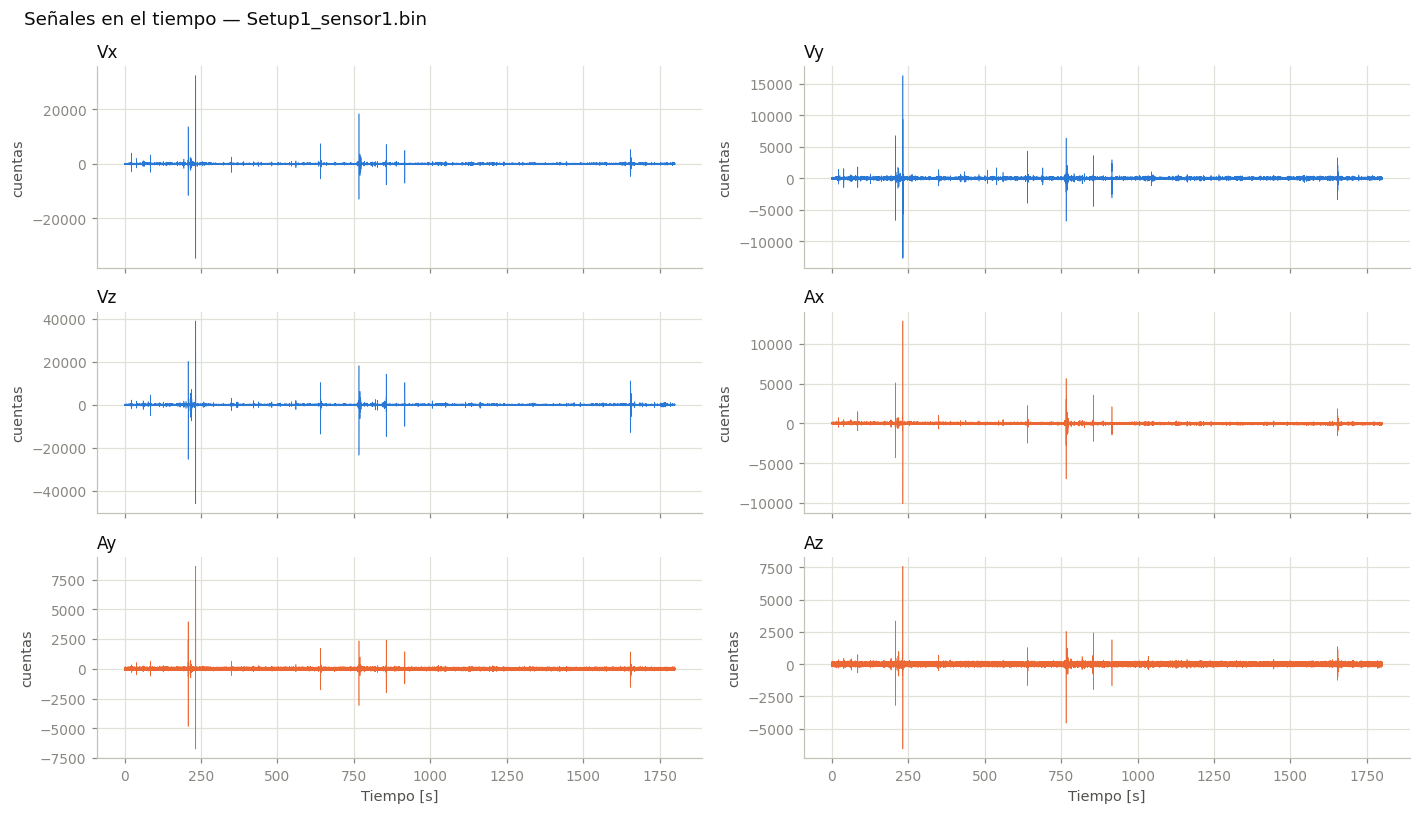

In [4]:
SENSOR_DEMO = files[0]
df, fs, info_demo = load_file(os.path.join(DATA_DIR, SENSOR_DEMO))
t = np.arange(len(df)) / fs

print(f"{SENSOR_DEMO}  |  fs = {fs} Hz  |  {len(df)} muestras  |  {len(df)/fs:.0f} s")
display(df.describe().T[["mean", "std", "min", "max"]].round(1))

fig, axes = plt.subplots(3, 2, figsize=(13, 7.5), sharex=True)
for ax, col in zip(axes.flat, df.columns):
    ax.plot(t, df[col].values - df[col].mean(),
            color=CAT[0] if col.startswith("V") else CAT[1], linewidth=0.4)
    ax.set_title(col, loc="left")
    ax.set_ylabel("cuentas")
for ax in axes[-1]:
    ax.set_xlabel("Tiempo [s]")
fig.suptitle(f"Señales en el tiempo — {SENSOR_DEMO}", x=0.02, ha="left", fontsize=12)
plt.tight_layout()
plt.show()

## Paso 4 — FFT

Dos herramientas distintas, con propósitos distintos:

- **FFT de amplitud** (`rfft`) sobre el registro completo: da la máxima resolución
  en frecuencia, pero su varianza no baja al aumentar la longitud del registro —
  el espectro se ve "peludo".
- **PSD de Welch**: promedia ~85 segmentos solapados. Pierde algo de resolución
  (df ≈ 0.024 Hz) pero reduce la varianza, que es lo que hace falta para localizar
  resonancias de forma fiable.

Se usan las dos: la FFT para el espectro crudo, Welch para todo lo modal.

,RMS [cuentas],f dominante [Hz],Amplitud
Canal,,,
Vx,160.5,11.088,1.44
Vy,106.6,7.018,1.70
Vz,220.4,9.409,2.14
Ax,70.2,6.751,0.43
Ay,56.4,21.597,0.40
Az,70.6,4.130,0.61


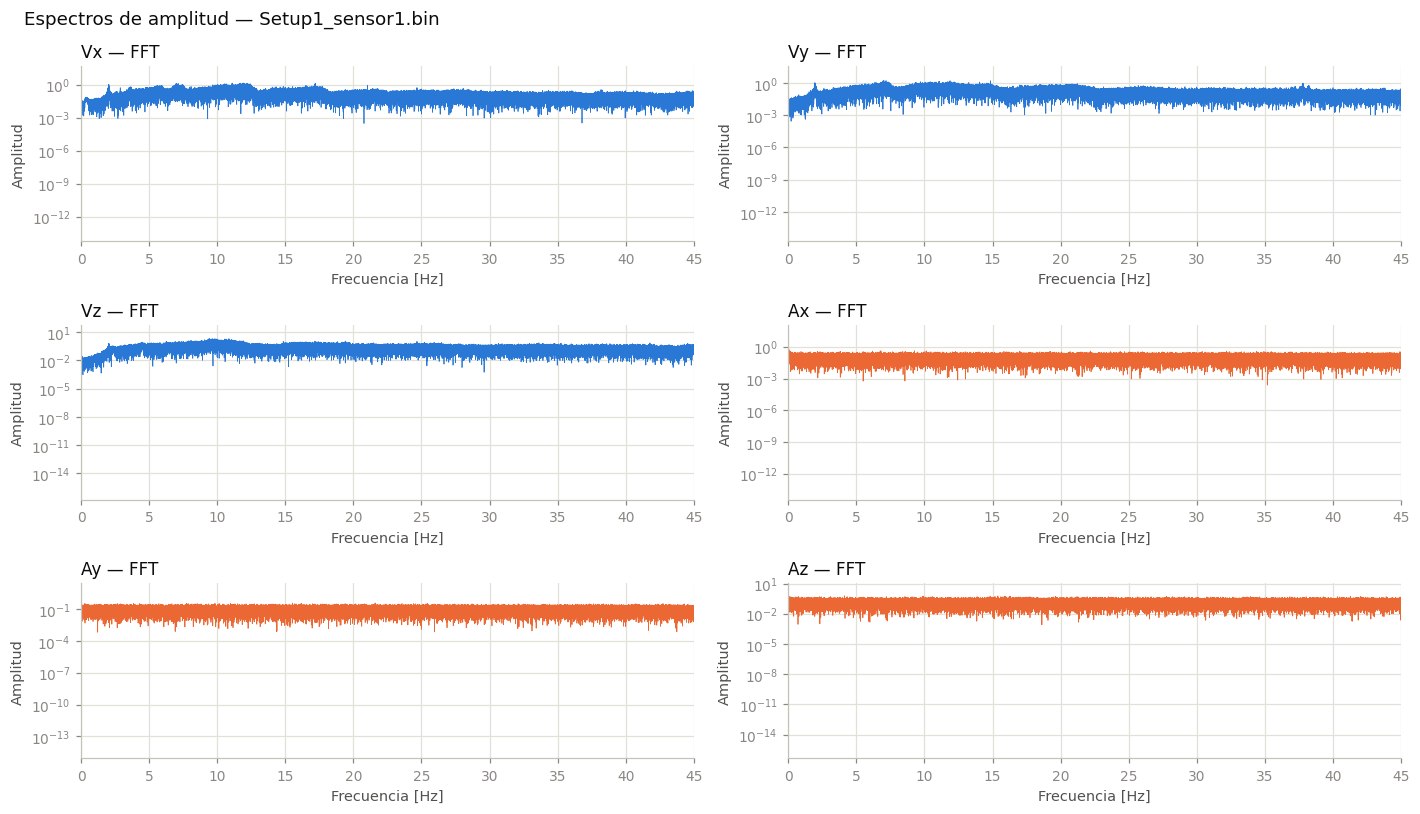

In [5]:
def compute_fft(signal, fs):
    """Espectro de amplitud de un solo lado."""
    n = len(signal)
    return np.fft.rfftfreq(n, 1 / fs), np.abs(np.fft.rfft(signal - signal.mean())) * 2 / n


def rms(x):
    return float(np.sqrt(np.mean(x ** 2)))


# --- resumen por canal del sensor de referencia ---
resumen = []
for col in df.columns:
    sig = df[col].values - df[col].mean()
    f_, A_ = compute_fft(sig, fs)
    m = (f_ >= 0.8) & (f_ <= 45)
    i = np.argmax(A_[m])
    resumen.append({"Canal": col, "RMS [cuentas]": round(rms(sig), 1),
                    "f dominante [Hz]": round(f_[m][i], 3),
                    "Amplitud": round(A_[m][i], 2)})
display(pd.DataFrame(resumen).set_index("Canal"))

fig, axes = plt.subplots(3, 2, figsize=(13, 7.5))
for ax, col in zip(axes.flat, df.columns):
    sig = df[col].values - df[col].mean()
    f_, A_ = compute_fft(sig, fs)
    ax.semilogy(f_, A_, color=CAT[0] if col.startswith("V") else CAT[1], linewidth=0.5)
    ax.set_xlim(0, 45)
    ax.set_title(f"{col} — FFT", loc="left")
    ax.set_xlabel("Frecuencia [Hz]")
    ax.set_ylabel("Amplitud")
fig.suptitle(f"Espectros de amplitud — {SENSOR_DEMO}", x=0.02, ha="left", fontsize=12)
plt.tight_layout()
plt.show()

Matriz Vx: 710227 muestras x 10 sensores


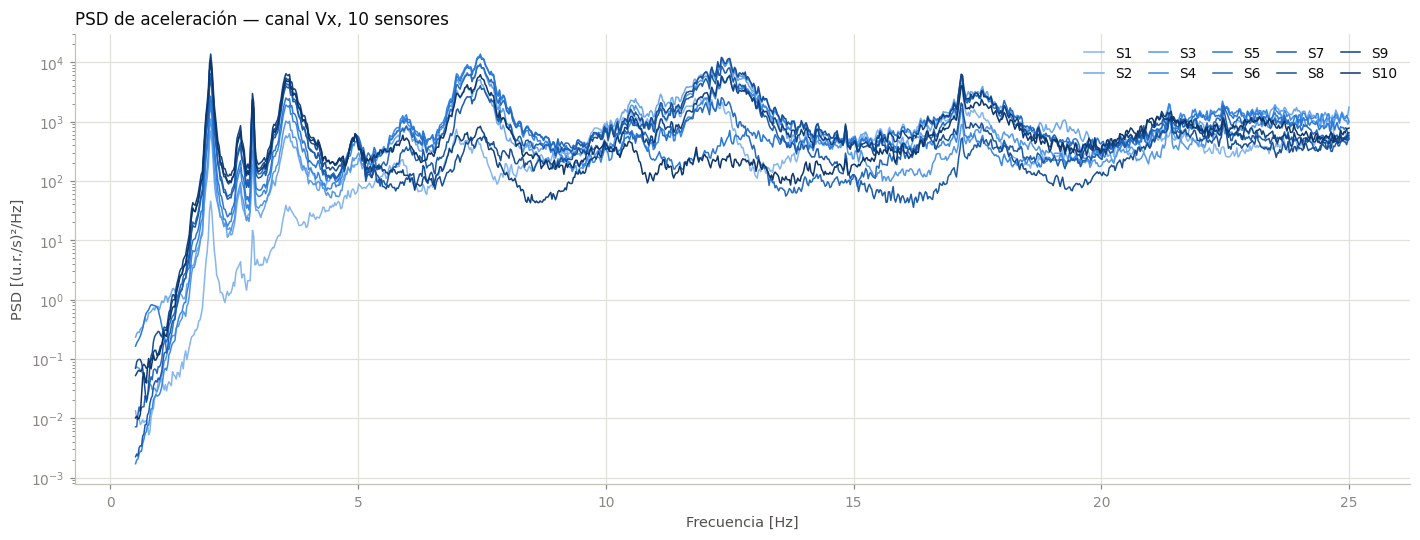

In [6]:
# --- PSD de Welch de los 10 sensores, canal de análisis ---
X, FS, INFOS = load_channel_matrix(files, CHANNEL)
print(f"Matriz {CHANNEL}: {X.shape[0]} muestras x {X.shape[1]} sensores")

fig, ax = plt.subplots(figsize=(13, 5))
for k in range(X.shape[1]):
    fw, Pw = welch(X[:, k], fs=FS, nperseg=NPERSEG)
    m = (fw >= 0.5) & (fw <= FMAX)
    ax.semilogy(fw[m], Pw[m], color=SEQ10[k], linewidth=1.0, label=f"S{k+1}")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel(f"PSD [{UNIDAD_PSD}]")   # u.r. = unidades relativas, ver paso 1
ax.set_title(f"PSD de {MAGNITUD} — canal {CHANNEL}, 10 sensores", loc="left")
ax.legend(ncol=5, loc="upper right", columnspacing=1.2, handlelength=1.4)
plt.tight_layout()
plt.show()

## Paso 5 — Calidad de datos

Dos comprobaciones que condicionan el resto:

1. **Nivel RMS por sensor** — detecta sensores mal acoplados o saturados.
2. **Coherencia entre pares** — si un sensor no es coherente con los demás en la
   banda de interés, no está midiendo la misma estructura (mal acoplamiento,
   ruido local) y contamina la identificación modal.

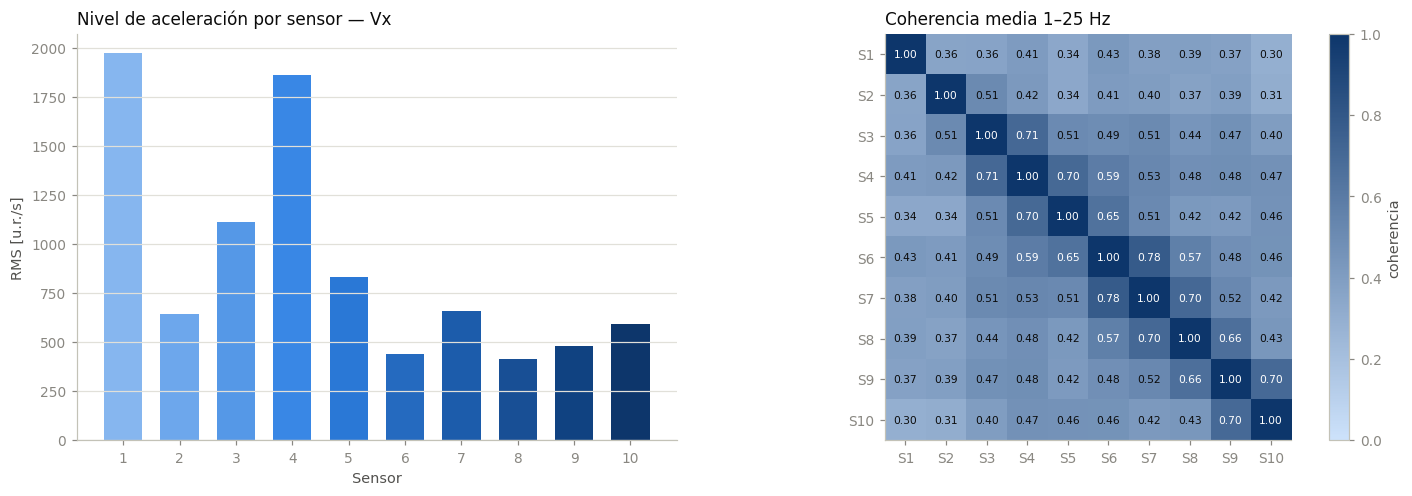

Sensores con menor coherencia media: S1 (0.37), S2 (0.39), S10 (0.44)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6),
                         gridspec_kw={"width_ratios": [1, 1.25]})

# --- RMS por sensor ---
rms_s = [rms(X[:, k]) for k in range(X.shape[1])]
axes[0].bar(np.arange(1, 11), rms_s, color=SEQ10, width=0.68)
axes[0].set_xticks(np.arange(1, 11))
axes[0].set_xlabel("Sensor")
axes[0].set_ylabel(f"RMS [{UNIDAD}]")
axes[0].set_title(f"Nivel de {MAGNITUD} por sensor — {CHANNEL}", loc="left")
axes[0].grid(axis="x", visible=False)

# --- coherencia media 1-25 Hz ---
nch = X.shape[1]
Cm = np.ones((nch, nch))
for i in range(nch):
    for j in range(i + 1, nch):
        fc, cxy = coherence(X[:, i], X[:, j], fs=FS, nperseg=NPERSEG)
        b = (fc >= 1) & (fc <= FMAX)
        Cm[i, j] = Cm[j, i] = cxy[b].mean()

im = axes[1].imshow(Cm, cmap=CMAP_SEQ, vmin=0, vmax=1)
axes[1].set_xticks(range(nch), [f"S{i+1}" for i in range(nch)])
axes[1].set_yticks(range(nch), [f"S{i+1}" for i in range(nch)])
axes[1].set_title(f"Coherencia media 1–{FMAX:.0f} Hz", loc="left")
axes[1].grid(visible=False)
for i in range(nch):
    for j in range(nch):
        axes[1].text(j, i, f"{Cm[i,j]:.2f}", ha="center", va="center", fontsize=7,
                     color="white" if Cm[i, j] > 0.55 else INK)
plt.colorbar(im, ax=axes[1], fraction=0.046, label="coherencia")
plt.tight_layout()
plt.show()

coh_mean = (Cm.sum(1) - 1) / (nch - 1)
flojos = [f"S{i+1} ({coh_mean[i]:.2f})" for i in np.argsort(coh_mean)[:3]]
print("Sensores con menor coherencia media:", ", ".join(flojos))

## Paso 6 — FDD (Frequency Domain Decomposition)

Se construye la matriz de densidad espectral cruzada **G(f)** de 10×10 (un canal
por sensor) promediando segmentos de Welch, y se hace la SVD en cada frecuencia:

$$G(f) = U(f)\,\Sigma(f)\,U(f)^H$$

En una resonancia bien excitada y con amortiguamiento bajo, la respuesta está
dominada por un modo: el **primer valor singular** presenta un pico y el primer
vector singular \(u_1\) aproxima la forma modal.

La implementación calcula la FFT de cada segmento una sola vez y acumula el
producto exterior — evita las 100 llamadas a `csd` del enfoque ingenuo.

FDD sobre 10 sensores | canal Vx
  segmentos promediados : 85
  resolución            : 0.0241 Hz
  banda                 : 0.8–25.0 Hz


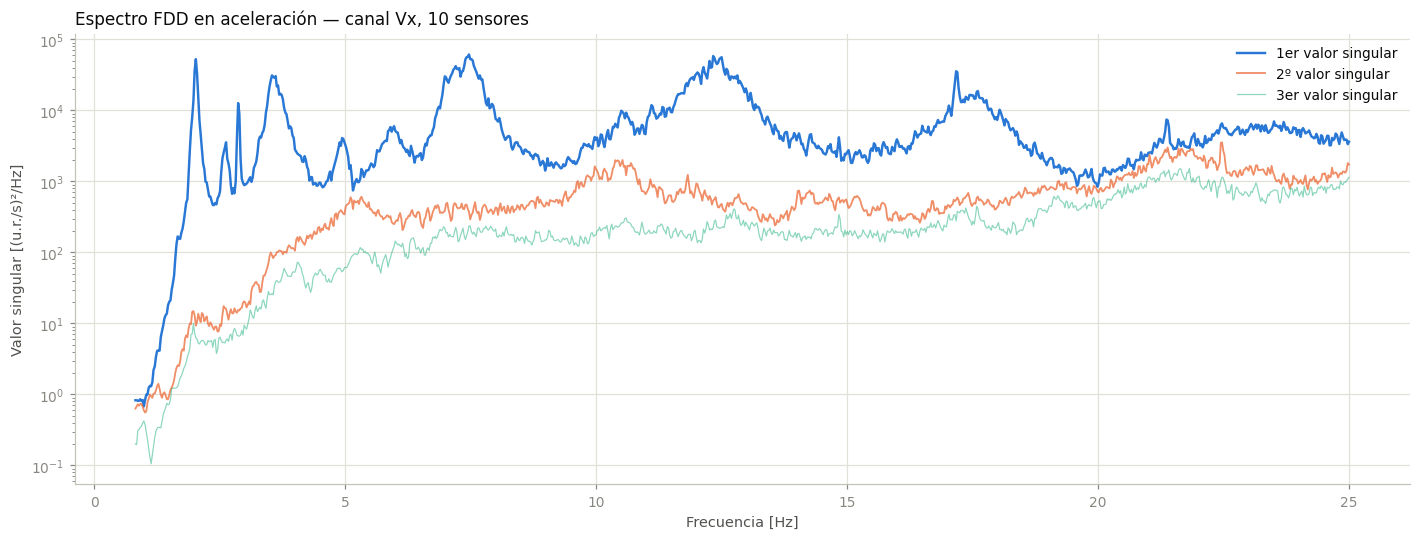

In [8]:
def cpsd_matrix(x, fs, nperseg=NPERSEG, noverlap=None):
    """Matriz de densidad espectral cruzada (Welch). -> f, G (nf, nch, nch), nseg"""
    n, nch = x.shape
    noverlap = nperseg // 2 if noverlap is None else noverlap
    step = nperseg - noverlap
    win = get_window("hann", nperseg)
    nseg = 1 + (n - nperseg) // step
    G = np.zeros((nperseg // 2 + 1, nch, nch), dtype=np.complex128)
    for k in range(nseg):
        seg = detrend(x[k * step: k * step + nperseg], axis=0, type="constant") * win[:, None]
        Xf = np.fft.rfft(seg, axis=0)                       # (nf, nch)
        G += Xf[:, :, None] * np.conj(Xf[:, None, :])
    G *= 1.0 / (fs * (win ** 2).sum() * nseg)               # escala a PSD
    G[1:-1] *= 2.0                                          # un solo lado
    return np.fft.rfftfreq(nperseg, 1 / fs), G, nseg


def fdd(x, fs, nperseg=NPERSEG, fmin=FMIN, fmax=FMAX):
    f, G, nseg = cpsd_matrix(x, fs, nperseg)
    m = (f >= fmin) & (f <= fmax)
    U, s, _ = np.linalg.svd(G[m])                            # SVD por frecuencia
    return f[m], s, U, nseg


freqs, sv, U, NSEG = fdd(X, FS)
print(f"FDD sobre {X.shape[1]} sensores | canal {CHANNEL}")
print(f"  segmentos promediados : {NSEG}")
print(f"  resolución            : {freqs[1]-freqs[0]:.4f} Hz")
print(f"  banda                 : {FMIN}–{FMAX} Hz")

fig, ax = plt.subplots(figsize=(13, 5))
for k, lab in enumerate(["1er valor singular", "2º valor singular", "3er valor singular"]):
    ax.semilogy(freqs, sv[:, k], color=CAT[k], linewidth=1.6 - 0.4 * k,
                alpha=1.0 - 0.25 * k, label=lab)
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel(f"Valor singular [{UNIDAD_PSD}]")
ax.set_title(f"Espectro FDD en {MAGNITUD} — canal {CHANNEL}, {X.shape[1]} sensores", loc="left")
ax.legend()
plt.tight_layout()
plt.show()

## Paso 7 — Detección de picos y discriminación modo vs. armónico

**Un pico alto no es un modo.** En este registro, los picos más energéticos son
tonos de banda estrecha producidos por una fuente (maquinaria) que domina el campo
de vibración. Para separarlos se calculan cuatro métricas en cada pico:

| Métrica | Qué mide | Modo estructural | Armónico / fuente |
|---|---|---|---|
| `sv1/sv2` | rango de la matriz espectral | ~3–100 | **> 100** (campo perfectamente coherente, una sola fuente) |
| `ζ` semipotencia | ancho de banda −3 dB | 0.3 – 6 % | ≪ 0.3 % (tono puro) |
| nº de cambios de signo | nodos espaciales de la forma | ≥ 1 en modos superiores | 0 (todo en fase, decae con la distancia a la fuente) |
| MPC | qué tan real es la forma | ≈ 1 | ≈ 1 (no discrimina, se reporta) |

**Criterio aplicado** — heurística, no verdad absoluta:

- `sv1/sv2 > 100` **y** sin cambios de signo → `armónico/fuente`
- `ζ` en [0.3 %, 6 %] **y** (hay nodos **o** `sv1/sv2 < 30`) → `modo estructural`
- resto → `dudoso`

> **Limitación importante:** el modo fundamental de un vano medido a lo largo de su
> luz también tiene 0 cambios de signo. Un pico marcado como `armónico/fuente`
> con `sv1/sv2` moderado merece revisión manual. La clasificación ordena el
> trabajo, no lo sustituye.

In [9]:
def half_power_damping(f, sv1_db, i):
    """Amortiguamiento [%] por el método de semipotencia sobre el 1er valor singular."""
    target = sv1_db[i] - 3.0
    l = i
    while l > 0 and sv1_db[l] > target:
        l -= 1
    r = i
    while r < len(sv1_db) - 1 and sv1_db[r] > target:
        r += 1
    return np.nan if r <= l else (f[r] - f[l]) / (2 * f[i]) * 100


def mode_shape(U, i):
    """1er vector singular, rotado a fase real y normalizado a máximo 1."""
    phi = U[i][:, 0]
    phi = phi * np.exp(-1j * np.angle(phi[np.argmax(np.abs(phi))]))
    return phi / np.max(np.abs(phi))


def n_sign_changes(phi, tol=0.15):
    r = phi.real
    r = r[np.abs(r) > tol]                       # ignora nodos y ruido
    return int(np.sum(np.diff(np.sign(r)) != 0))


def mpc(phi):
    """Modal phase collinearity: 1 = forma real (modo normal clásico)."""
    return float(np.sum(phi.real ** 2) / np.sum(np.abs(phi) ** 2))


def classify(ratio, zeta, nsign):
    if ratio > 100 and nsign == 0:
        return "armónico/fuente"
    if not (0.3 <= zeta <= 6.0):
        return "dudoso"
    if nsign >= 1 or ratio < 30:
        return "modo estructural"
    return "dudoso"


# ---------- detección ----------
sv1_db = 10 * np.log10(sv[:, 0])
df_res = freqs[1] - freqs[0]
pk, props = find_peaks(sv1_db, prominence=5, distance=max(1, int(0.10 / df_res)))

reg = []
for i in pk:
    phi = mode_shape(U, i)
    ratio = sv[i, 0] / sv[i, 1]
    zeta = half_power_damping(freqs, sv1_db, i)
    ns = n_sign_changes(phi)
    reg.append({"i": i, "f [Hz]": round(float(freqs[i]), 3),
                "prom [dB]": round(float(props["prominences"][list(pk).index(i)]), 1),
                "sv1/sv2": round(float(ratio), 1),
                "ζ [%]": round(float(zeta), 2),
                "nodos": ns, "MPC": round(mpc(phi), 3),
                "clase": classify(ratio, zeta, ns)})

peaks = pd.DataFrame(reg).sort_values("f [Hz]").reset_index(drop=True)
display(peaks.drop(columns="i").style.apply(
    lambda c: [f"color: {STATUS.get(v, INK)}; font-weight: 600" for v in c]
    if c.name == "clase" else ["" for _ in c], axis=0))

print("\nRecuento por clase:")
print(peaks["clase"].value_counts().to_string())

,f [Hz],prom [dB],sv1/sv2,ζ [%],nodos,MPC,clase
0,2.023000,20.600000,5654.300000,2.380000,0,0.995000,armónico/fuente
1,2.625000,7.300000,220.200000,3.210000,0,0.992000,armónico/fuente
2,2.866000,11.600000,818.100000,1.260000,0,0.991000,armónico/fuente
3,3.540000,16.200000,341.700000,4.420000,0,0.987000,armónico/fuente
4,4.937000,6.900000,10.900000,2.930000,0,0.990000,modo estructural
5,5.973000,5.100000,24.000000,3.830000,1,0.993000,modo estructural
6,7.466000,18.600000,163.600000,2.420000,1,0.997000,modo estructural
7,12.330000,16.100000,108.000000,1.760000,1,0.994000,modo estructural
8,17.171000,12.900000,64.900000,0.350000,2,0.979000,modo estructural



Recuento por clase:
clase
modo estructural    5
armónico/fuente     4


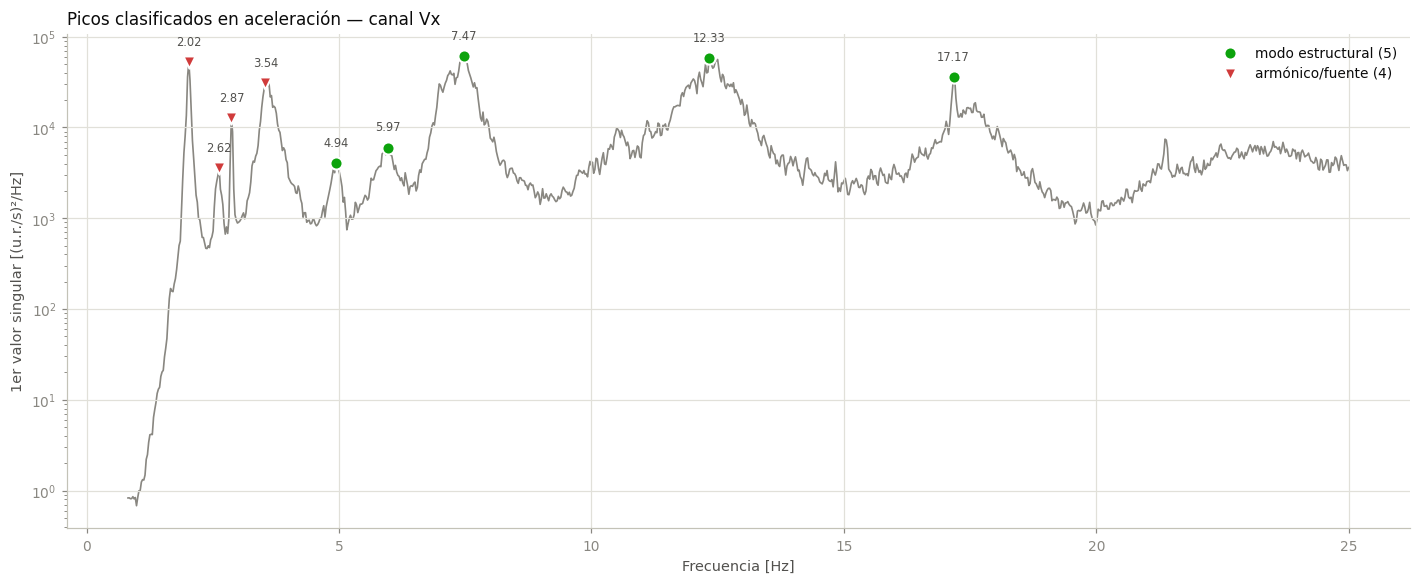

In [10]:
fig, ax = plt.subplots(figsize=(13, 5.4))
ax.semilogy(freqs, sv[:, 0], color=MUTED, linewidth=1.1, zorder=1)

for clase, marker in [("modo estructural", "o"), ("dudoso", "s"), ("armónico/fuente", "v")]:
    sub = peaks[peaks["clase"] == clase]
    if sub.empty:
        continue
    ax.scatter(sub["f [Hz]"], sv[sub["i"].values, 0], s=64, marker=marker,
               color=STATUS[clase], edgecolor="white", linewidth=1.4,
               zorder=3, label=f"{clase} ({len(sub)})")

for _, r in peaks.iterrows():
    ax.annotate(f"{r['f [Hz]']:.2f}", (r["f [Hz]"], sv[int(r["i"]), 0]),
                textcoords="offset points", xytext=(0, 11), ha="center",
                fontsize=7.5, color=INK2)

ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel(f"1er valor singular [{UNIDAD_PSD}]")
ax.set_title(f"Picos clasificados en {MAGNITUD} — canal {CHANNEL}", loc="left")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Paso 8 — Formas modales y matriz MAC

El **MAC** (Modal Assurance Criterion) mide el parecido entre dos formas:
1 = idénticas, 0 = ortogonales. Modos estructurales distintos deben dar MAC bajo
(< ~0.3) fuera de la diagonal. **Si todos los "modos" dan MAC ≈ 1 entre sí, no son
modos distintos** — es la firma de una única fuente dominante.

Las formas se dibujan contra el **índice de sensor**, no contra coordenadas
reales: para interpretarlas físicamente hace falta el plano de posiciones de los
10 sensores sobre la estructura.

Dos picos vecinos con MAC alto entre sí **no son dos modos**: son el mismo modo detectado dos veces (lóbulos laterales, fuga espectral o un pico partido por el ruido). Al final del paso se agrupan los candidatos con MAC > 0.80 y se conserva uno por grupo — el de mayor prominencia.

5 candidatos a modo estructural en el canal Vx


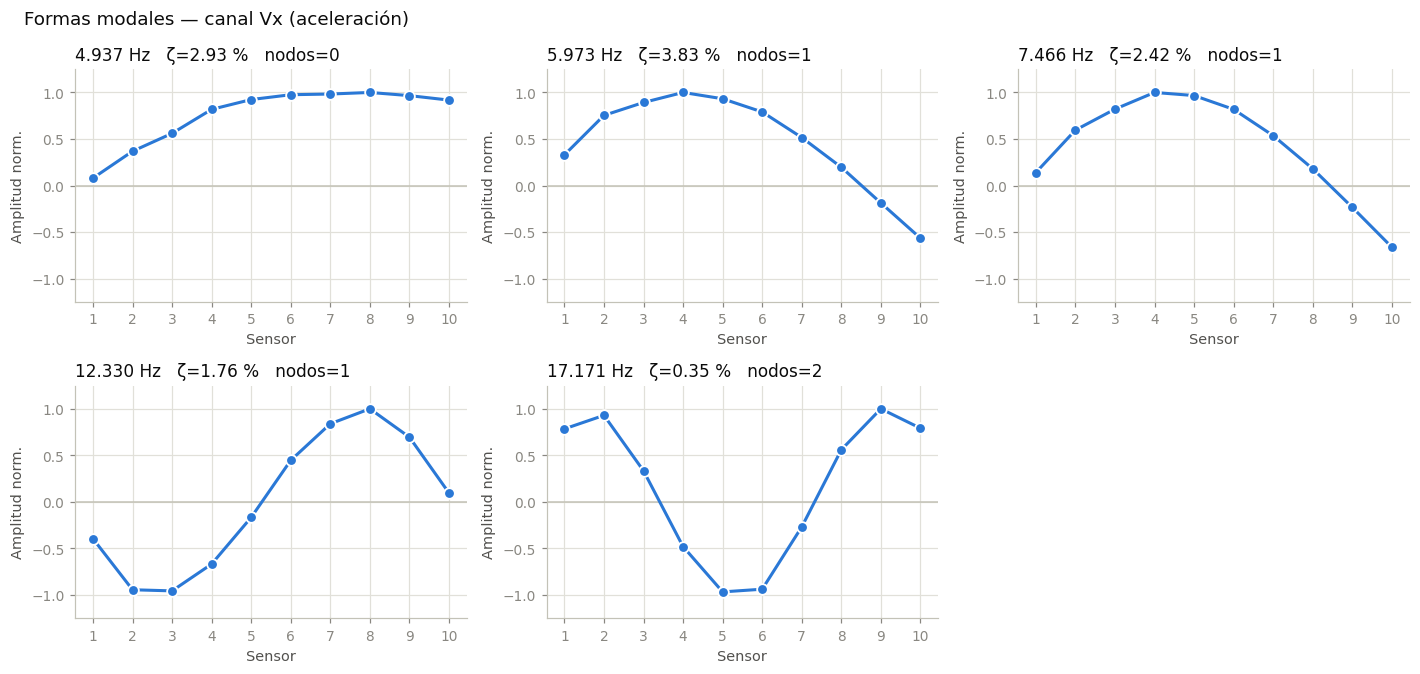

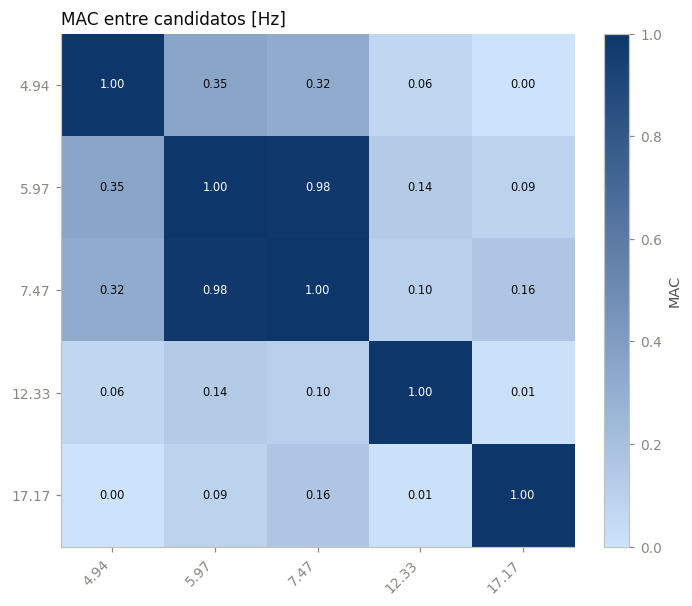

MAC fuera de la diagonal: máx = 0.98, medio = 0.22
AVISO: MAC alto entre candidatos, revisar si son modos independientes.

1 grupo(s) de candidatos con la misma forma (MAC > 0.8):
   [5.973, 7.466]  ->  misma forma modal, se conserva uno solo

=== 4 MODO(S) INDEPENDIENTE(S) — canal Vx ===


,f [Hz],prom [dB],sv1/sv2,ζ [%],nodos,MPC
0,4.937,6.9,10.9,2.93,0,0.990
1,7.466,18.6,163.6,2.42,1,0.997
2,12.330,16.1,108.0,1.76,1,0.994
3,17.171,12.9,64.9,0.35,2,0.979


In [11]:
def mac_matrix(P):
    num = np.abs(P.conj() @ P.T) ** 2
    den = np.real(np.sum(np.abs(P) ** 2, axis=1))
    return num / np.outer(den, den)


modos = peaks[peaks["clase"] == "modo estructural"].reset_index(drop=True)
print(f"{len(modos)} candidatos a modo estructural en el canal {CHANNEL}")

if len(modos):
    P = np.array([mode_shape(U, int(r["i"])) for _, r in modos.iterrows()])
    x_s = np.arange(1, X.shape[1] + 1)

    ncol = min(3, len(modos))
    nrow = int(np.ceil(len(modos) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(13, 3.1 * nrow), squeeze=False)
    for k, (_, r) in enumerate(modos.iterrows()):
        ax = axes[k // ncol][k % ncol]
        phi = P[k].real
        ax.axhline(0, color="#c3c2b7", linewidth=1)
        ax.plot(x_s, phi, color=CAT[0], linewidth=2, marker="o",
                markersize=7, markeredgecolor="white", markeredgewidth=1.2)
        ax.set_ylim(-1.25, 1.25)
        ax.set_xticks(x_s)
        ax.set_title(f"{r['f [Hz]']:.3f} Hz   ζ={r['ζ [%]']:.2f} %   "
                     f"nodos={r['nodos']}", loc="left")
        ax.set_xlabel("Sensor")
        ax.set_ylabel("Amplitud norm.")
    for k in range(len(modos), nrow * ncol):
        axes[k // ncol][k % ncol].axis("off")
    fig.suptitle(f"Formas modales — canal {CHANNEL} ({MAGNITUD})", x=0.02, ha="left", fontsize=12)
    plt.tight_layout()
    plt.show()

    # ---- MAC ----
    # con un solo candidato no hay nada que comparar: la matriz sería 1x1
    M = mac_matrix(P)
    lab = [f"{v:.2f}" for v in modos["f [Hz]"]]
    fig, ax = plt.subplots(figsize=(6.4, 5.6))
    im = ax.imshow(M, cmap=CMAP_SEQ, vmin=0, vmax=1)
    ax.set_xticks(range(len(lab)), lab, rotation=45, ha="right")
    ax.set_yticks(range(len(lab)), lab)
    ax.set_title("MAC entre candidatos [Hz]", loc="left")
    ax.grid(visible=False)
    for i in range(len(lab)):
        for j in range(len(lab)):
            ax.text(j, i, f"{M[i,j]:.2f}", ha="center", va="center", fontsize=7.5,
                    color="white" if M[i, j] > 0.55 else INK)
    plt.colorbar(im, ax=ax, fraction=0.046, label="MAC")
    plt.tight_layout()
    plt.show()

    THR = 0.80
    if len(modos) > 1:
        off = M[~np.eye(len(M), dtype=bool)]
        print(f"MAC fuera de la diagonal: máx = {off.max():.2f}, medio = {off.mean():.2f}")
        print("Modos bien separados." if off.max() < 0.5
              else "AVISO: MAC alto entre candidatos, revisar si son modos independientes.")

        # ---- deduplicación: candidatos que comparten forma modal ----
        grupo = -np.ones(len(modos), dtype=int)
        g = 0
        for i in range(len(modos)):
            if grupo[i] >= 0:
                continue
            grupo[i] = g
            for j in range(i + 1, len(modos)):
                if grupo[j] < 0 and M[i, j] > THR:
                    grupo[j] = g
            g += 1
        modos["grupo"] = grupo

        dup = [gr for gr in range(g) if (grupo == gr).sum() > 1]
        if dup:
            print(f"\n{len(dup)} grupo(s) de candidatos con la misma forma (MAC > {THR}):")
            for gr in dup:
                fs_gr = modos.loc[modos["grupo"] == gr, "f [Hz]"].tolist()
                print(f"   {fs_gr}  ->  misma forma modal, se conserva uno solo")
        else:
            print(f"\nNingún par de candidatos supera MAC {THR}: todas las formas son distintas.")
    else:
        print("Un solo candidato: no hay MAC entre modos que calcular.")
        modos["grupo"] = 0

    modos_unicos = (modos.loc[modos.groupby("grupo")["prom [dB]"].idxmax()]
                         .sort_values("f [Hz]").reset_index(drop=True))
    print(f"\n=== {len(modos_unicos)} MODO(S) INDEPENDIENTE(S) — canal {CHANNEL} ===")
    display(modos_unicos[["f [Hz]", "prom [dB]", "sv1/sv2", "ζ [%]", "nodos", "MPC"]])
else:
    print(f"Ningún candidato a modo estructural en el canal {CHANNEL}.")
    print("Con los canales de aceleración esto es lo esperado: ver paso 10.")
    modos_unicos = modos.copy()


## Paso 9 — Resumen: barrido de los tres canales

La identificación se repite en `Vx`, `Vy` y `Vz`. Un modo real de la estructura
suele aparecer en más de un canal y en varios sensores; un tono de máquina
aparece con `sv1/sv2` enorme y forma sin nodos.

=== CANDIDATOS A MODO ESTRUCTURAL ===


prom [dB]  sv1/sv2  ζ [%]  nodos             clase
Canal        f [Hz]                                                    
aZ (geófono) 2.866        10.5      7.5   1.26      0  modo estructural
aY (geófono) 3.275         7.3     19.0   1.10      0  modo estructural
aX (geófono) 4.937         6.9     10.9   2.93      0  modo estructural
             5.973         5.1     24.0   3.83      1  modo estructural
aY (geófono) 7.345        12.3    250.4   4.75      1  modo estructural
aX (geófono) 7.466        18.6    163.6   2.42      1  modo estructural
aY (geófono) 11.102       10.2     15.6   3.04      1  modo estructural
aX (geófono) 12.330       16.1    108.0   1.76      1  modo estructural
aY (geófono) 14.859       13.1      3.0   0.57      1  modo estructural
aX (geófono) 17.171       12.9     64.9   0.35      2  modo estructural
aY (geófono) 21.241        7.7     11.7   2.61      2  modo estructural


=== TONOS ARMÓNICOS / FUENTE (no son modos) ===


prom [dB]  sv1/sv2  ζ [%]  nodos            clase
Canal        f [Hz]                                                   
aY (geófono) 1.951        25.0  12405.7   3.09      0  armónico/fuente
aX (geófono) 2.023        20.6   5654.3   2.38      0  armónico/fuente
aZ (geófono) 2.023        18.9    276.5   2.38      0  armónico/fuente
aX (geófono) 2.625         7.3    220.2   3.21      0  armónico/fuente
             2.866        11.6    818.1   1.26      0  armónico/fuente
             3.540        16.2    341.7   4.42      0  armónico/fuente
aZ (geófono) 10.669       11.6    184.4   2.14      0  armónico/fuente
             19.459       10.1    104.2   0.99      0  armónico/fuente

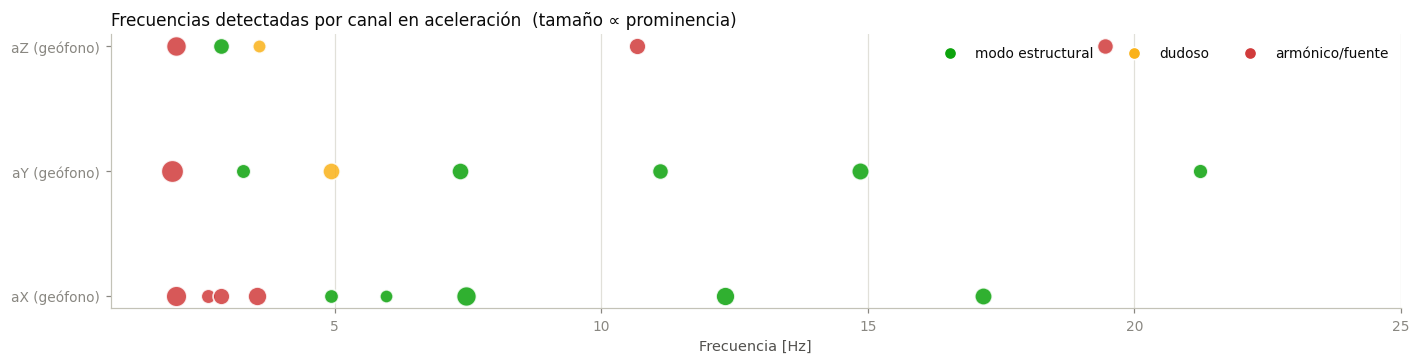

Resultados guardados en: C:\Users\verwalter\Desktop\Cesar\Sensequake\PythonScripts\Post_Process_Data\test1_frecuencias_identificadas.csv


In [12]:
def etiqueta(channel):
    """Nombre legible: magnitud + eje + instrumento."""
    eje = channel[1].upper()
    if channel.startswith("A"):
        return f"a{eje} (MEMS)"
    return f"a{eje} (geófono)" if DOMINIO == "aceleracion" else f"v{eje} (geófono)"


def identificar(channel):
    Xc, fsc, _ = load_channel_matrix(files, channel)
    fq, s_, U_, _ = fdd(Xc, fsc)
    db = 10 * np.log10(s_[:, 0])
    dfres = fq[1] - fq[0]
    pks, pr = find_peaks(db, prominence=5, distance=max(1, int(0.10 / dfres)))
    out = []
    for n_, i in enumerate(pks):
        phi = mode_shape(U_, i)
        ratio, ns = s_[i, 0] / s_[i, 1], n_sign_changes(phi)
        z = half_power_damping(fq, db, i)
        out.append({"Canal": etiqueta(channel), "f [Hz]": round(float(fq[i]), 3),
                    "prom [dB]": round(float(pr["prominences"][n_]), 1),
                    "sv1/sv2": round(float(ratio), 1), "ζ [%]": round(float(z), 2),
                    "nodos": ns, "clase": classify(ratio, z, ns)})
    return pd.DataFrame(out)


todo = pd.concat([identificar(c) for c in ["Vx", "Vy", "Vz"]], ignore_index=True)

print("=== CANDIDATOS A MODO ESTRUCTURAL ===")
est = todo[todo["clase"] == "modo estructural"].sort_values("f [Hz]")
display(est.set_index(["Canal", "f [Hz]"]))

print("\n=== TONOS ARMÓNICOS / FUENTE (no son modos) ===")
arm = todo[todo["clase"] == "armónico/fuente"].sort_values("f [Hz]")
display(arm.set_index(["Canal", "f [Hz]"]))

# --- mapa de frecuencias por canal ---
fig, ax = plt.subplots(figsize=(13, 3.4))
for yi, c in enumerate(["Vx", "Vy", "Vz"]):
    sub = todo[todo["Canal"] == etiqueta(c)]
    for _, r in sub.iterrows():
        ax.scatter(r["f [Hz]"], yi, s=40 + 7 * r["prom [dB]"],
                   color=STATUS[r["clase"]], alpha=0.85,
                   edgecolor="white", linewidth=1.1, zorder=3)
ax.set_yticks(range(3), [etiqueta(c) for c in ["Vx", "Vy", "Vz"]])
ax.set_xlabel("Frecuencia [Hz]")
ax.set_xlim(FMIN, FMAX)
ax.set_title(f"Frecuencias detectadas por canal en {MAGNITUD}  (tamaño ∝ prominencia)", loc="left")
ax.grid(axis="y", visible=False)
handles = [plt.Line2D([], [], marker="o", linestyle="", markersize=8,
                      markerfacecolor=v, markeredgecolor="white", label=k)
           for k, v in STATUS.items()]
ax.legend(handles=handles, ncol=3, loc="upper right")
plt.tight_layout()
plt.show()

out_csv = os.path.join(POST_DIR, "test1_frecuencias_identificadas.csv")
os.makedirs(POST_DIR, exist_ok=True)
todo.to_csv(out_csv, index=False)
print("Resultados guardados en:", out_csv)

### Tabla de modos por dirección — aceleración en X e Y

Para cada dirección se listan los modos estructurales ya deduplicados por MAC, con la **forma modal completa**: la amplitud normalizada en cada uno de los 10 sensores. Es la tabla que resume el resultado del análisis.

Las amplitudes están normalizadas a máximo 1 y llevan signo: el cambio de signo entre sensores marca un nodo. `nodos` cuenta esos cambios.

> Recuerda que los sensores 1 y 2 tienen coherencia baja con el resto (paso 5): sus amplitudes son las menos fiables de la fila.

In [13]:
def modos_direccion(channel, thr_mac=0.80):
    """Modos estructurales de un canal, deduplicados, con su forma modal."""
    Xc, fsc, _ = load_channel_matrix(files, channel)
    fq, s_, U_, _ = fdd(Xc, fsc)
    db = 10 * np.log10(s_[:, 0])
    pks, pr = find_peaks(db, prominence=5,
                         distance=max(1, int(0.10 / (fq[1] - fq[0]))))
    filas, formas = [], []
    for k, i in enumerate(pks):
        phi = mode_shape(U_, i)
        ratio = s_[i, 0] / s_[i, 1]
        z = half_power_damping(fq, db, i)
        ns = n_sign_changes(phi)
        if classify(ratio, z, ns) != "modo estructural":
            continue
        filas.append({"Dirección": etiqueta(channel), "f [Hz]": round(float(fq[i]), 3),
                      "ζ [%]": round(float(z), 2), "nodos": ns,
                      "sv1/sv2": round(float(ratio), 1),
                      "prom [dB]": round(float(pr["prominences"][k]), 1)})
        formas.append(phi)

    if not filas:
        return pd.DataFrame(), []

    # deduplicación por MAC: dos picos con la misma forma son el mismo modo
    Pm = np.array(formas)
    num = np.abs(Pm.conj() @ Pm.T) ** 2
    den = np.real(np.sum(np.abs(Pm) ** 2, 1))
    M = num / np.outer(den, den)
    keep, usados = [], set()
    for i in range(len(filas)):
        if i in usados:
            continue
        grupo = [j for j in range(i, len(filas)) if j not in usados and M[i, j] > thr_mac]
        mejor = max(grupo, key=lambda j: filas[j]["prom [dB]"])
        keep.append(mejor)
        usados.update(grupo)
    keep.sort(key=lambda j: filas[j]["f [Hz]"])
    return pd.DataFrame([filas[j] for j in keep]), [formas[j] for j in keep]


tablas, formas_all = [], []
for ch in ["Vx", "Vy"]:                       # dirección X e Y
    t, fm = modos_direccion(ch)
    if len(t):
        for k in range(10):
            t[f"S{k+1}"] = [round(float(p.real[k]), 2) for p in fm]
        tablas.append(t)
        formas_all += list(zip(t["Dirección"], t["f [Hz]"], fm))

tabla_modos = pd.concat(tablas, ignore_index=True)
print(f"=== MODOS EN ACELERACIÓN, DIRECCIONES X e Y — {len(tabla_modos)} modos, 10 sensores ===")
display(tabla_modos.set_index(["Dirección", "f [Hz]"]))

ruta = os.path.join(POST_DIR, "test1_modos_aceleracion_XY.csv")
tabla_modos.to_csv(ruta, index=False)
print("Guardada en:", ruta)

=== MODOS EN ACELERACIÓN, DIRECCIONES X e Y — 9 modos, 10 sensores ===


ζ [%]  nodos  sv1/sv2  prom [dB]    S1    S2    S3    S4  \
Dirección    f [Hz]                                                             
aX (geófono) 4.937    2.93      0     10.9        6.9  0.08  0.37  0.56  0.82   
             7.466    2.42      1    163.6       18.6  0.14  0.60  0.82  1.00   
             12.330   1.76      1    108.0       16.1 -0.40 -0.94 -0.96 -0.67   
             17.171   0.35      2     64.9       12.9  0.78  0.93  0.33 -0.48   
aY (geófono) 3.275    1.10      0     19.0        7.3  0.07  0.17  0.26  0.29   
             7.345    4.75      1    250.4       12.3  0.23  0.73  0.89  1.00   
             11.102   3.04      1     15.6       10.2 -0.24 -0.34 -0.29 -0.15   
             14.859   0.57      1      3.0       13.1  0.26  0.98  1.00  0.77   
             21.241   2.61      2     11.7        7.7  0.44  0.97  0.40 -0.34   

                       S5    S6    S7    S8    S9   S10  
Dirección    f [Hz]                                      
aX (geófono) 4.937   0.92  0.98  0.98  1.00  0.97  0.92  
             7.466   0.97  0.82  0.54  0.18 -0.23 -0.66  
             12.330 -0.17  0.45  0.84  1.00  0.70  0.10  
             17.171 -0.97 -0.94 -0.27  0.56  1.00  0.79  
aY (geófono) 3.275   0.42  0.59  0.69  0.67  0.84  1.00  
             7.345   0.95  0.88  0.65  0.39  0.00 -0.45  
             11.102  0.04  0.28  0.49  0.76  0.93  1.00  
             14.859  0.38 -0.07 -0.43 -0.59 -0.42  0.09  
             21.241 -0.85 -0.97 -0.41  0.40  1.00  0.77

Guardada en: C:\Users\verwalter\Desktop\Cesar\Sensequake\PythonScripts\Post_Process_Data\test1_modos_aceleracion_XY.csv


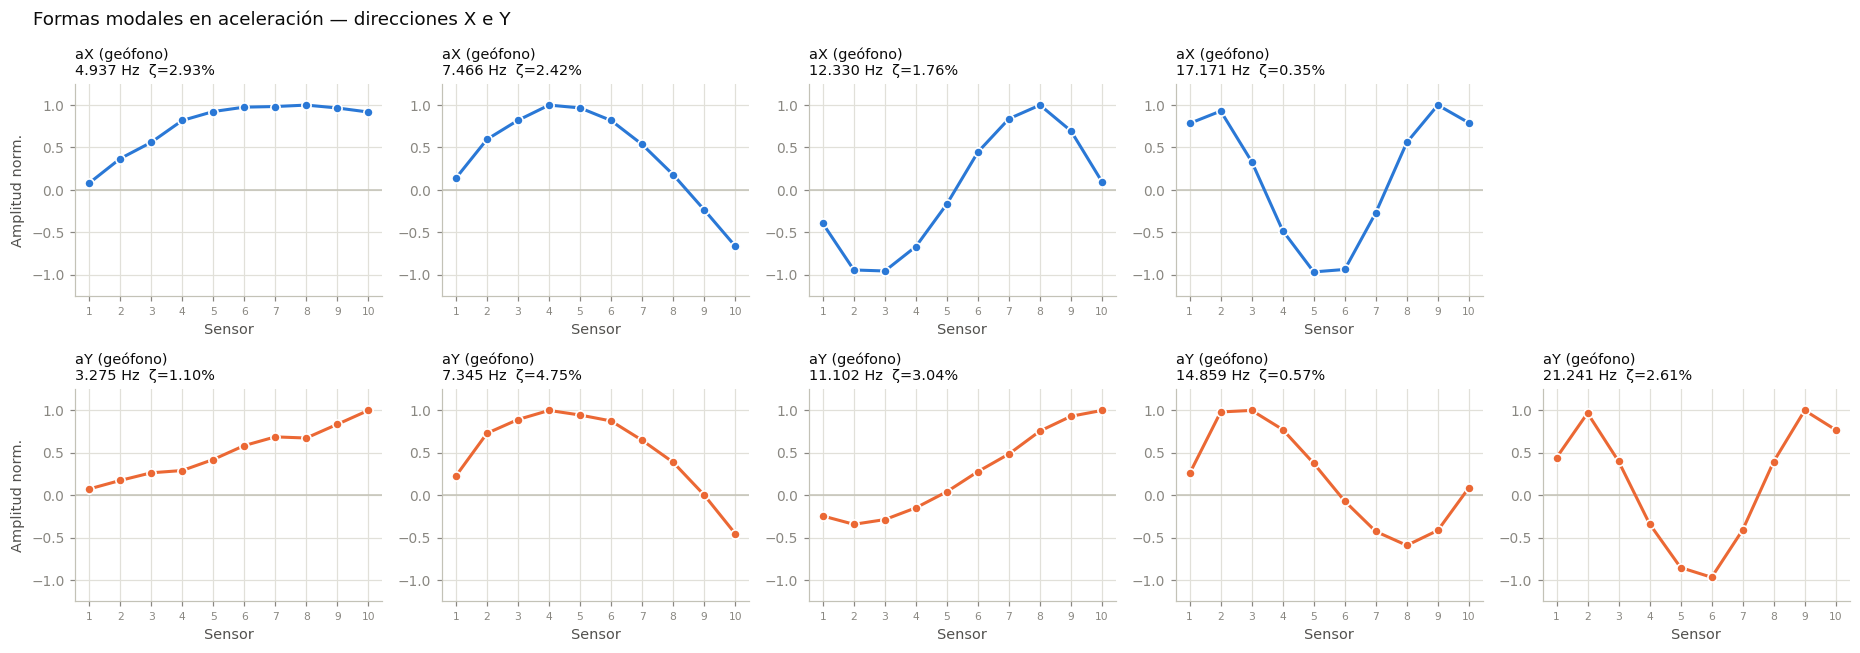

In [14]:
# --- formas modales de X e Y, una fila por dirección ---
nrow = len(tablas)
ncol = max(len(t) for t in tablas)
fig, axes = plt.subplots(nrow, ncol, figsize=(3.4 * ncol, 3.0 * nrow), squeeze=False)
x_s = np.arange(1, 11)

k = 0
for r, t in enumerate(tablas):
    for c_ in range(ncol):
        ax = axes[r][c_]
        if c_ >= len(t):
            ax.axis("off")
            continue
        fila = t.iloc[c_]
        phi = formas_all[k][2].real; k += 1
        ax.axhline(0, color="#c3c2b7", linewidth=1)
        ax.plot(x_s, phi, color=CAT[r], linewidth=2, marker="o", markersize=6,
                markeredgecolor="white", markeredgewidth=1.1)
        ax.set_ylim(-1.25, 1.25)
        ax.set_xticks(x_s, [str(v) for v in x_s], fontsize=7)
        ax.set_title(f"{fila['Dirección']}\n{fila['f [Hz]']:.3f} Hz  ζ={fila['ζ [%]']:.2f}%",
                     loc="left", fontsize=9.5)
        if c_ == 0:
            ax.set_ylabel("Amplitud norm.")
        ax.set_xlabel("Sensor")

fig.suptitle("Formas modales en aceleración — direcciones X e Y",
             x=0.02, ha="left", fontsize=12)
plt.tight_layout()
plt.show()

### Respuesta del geófono

Los geófonos tienen f₀ ≈ 4.5 Hz y ζ ≈ 0.7. **Por debajo de f₀ la respuesta cae a
12 dB/octava**, así que las amplitudes por debajo de ~4.5 Hz están atenuadas.
Como los 10 equipos tienen f₀ casi idéntica, las *formas modales* apenas se ven
afectadas, pero las amplitudes absolutas sí. La tabla siguiente da el factor de
respuesta en cada frecuencia identificada.

Geófono Vx: f0 = 4.52 +/- 0.10 Hz, ζ = 0.689, sensibilidad = 27.81 +/- 0.51 V/m/s


,respuesta,atenuación [dB]
f [Hz],,
1.951,0.185,-14.7
2.023,0.198,-14.0
2.625,0.325,-9.8
2.866,0.380,-8.4
3.275,0.475,-6.5
3.540,0.535,-5.4
3.588,0.546,-5.3
4.937,0.786,-2.1
5.973,0.887,-1.0


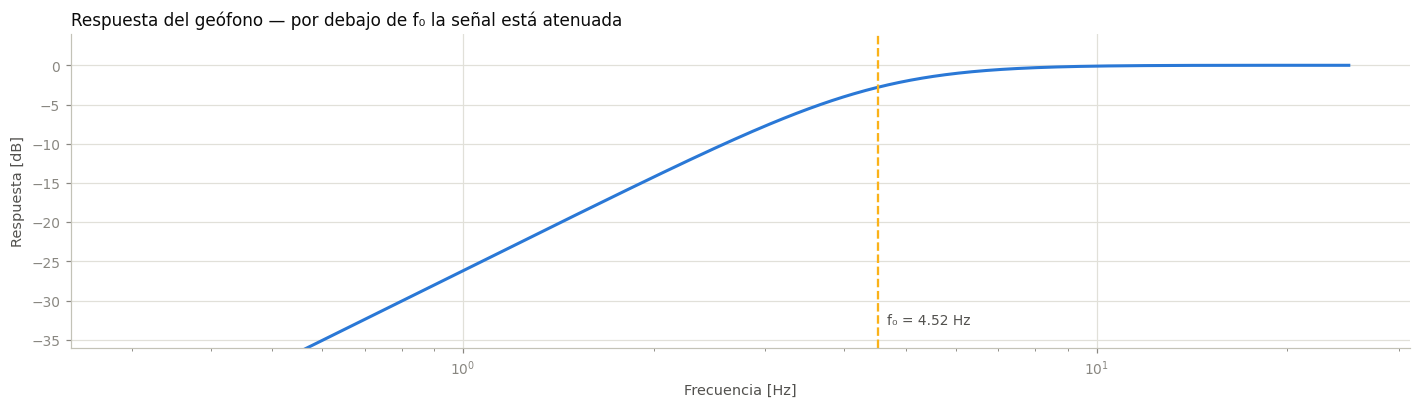

In [15]:
def geophone_response(f, f0, zeta):
    """Respuesta normalizada velocidad -> tensión de un geófono."""
    r = np.asarray(f, dtype=float) / f0
    return r ** 2 / np.sqrt((1 - r ** 2) ** 2 + (2 * zeta * r) ** 2)


# la respuesta del geófono solo aplica a los canales de velocidad
_infos_geo = INFOS if CHANNEL.startswith("V") else load_channel_matrix(files, CHANNEL_GEO)[2]
g = np.array([geophone_params(i, CHANNEL_GEO) for i in _infos_geo])
f0_m, z_m = g[:, 2].mean(), g[:, 1].mean()
print(f"Geófono {CHANNEL_GEO}: f0 = {f0_m:.2f} +/- {g[:,2].std():.2f} Hz, "
      f"ζ = {z_m:.3f}, sensibilidad = {g[:,0].mean():.2f} +/- {g[:,0].std():.2f} V/m/s")

fr = np.sort(todo["f [Hz]"].unique())
resp = geophone_response(fr, f0_m, z_m)
display(pd.DataFrame({"f [Hz]": fr, "respuesta": resp.round(3),
                      "atenuación [dB]": (20 * np.log10(resp)).round(1)})
        .query("`f [Hz]` <= 12").set_index("f [Hz]"))

fig, ax = plt.subplots(figsize=(13, 3.8))
fx = np.linspace(0.3, FMAX, 800)
ax.semilogx(fx, 20 * np.log10(geophone_response(fx, f0_m, z_m)), color=CAT[0], linewidth=2)
ax.axvline(f0_m, color=STATUS["dudoso"], linewidth=1.5, linestyle="--")
ax.annotate(f"f₀ = {f0_m:.2f} Hz", (f0_m, -33), xytext=(6, 0),
            textcoords="offset points", color=INK2, fontsize=9)
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel("Respuesta [dB]")
ax.set_ylim(-36, 4)
ax.set_title("Respuesta del geófono — por debajo de f₀ la señal está atenuada", loc="left")
plt.tight_layout()
plt.show()

## Paso 10 — Identificación modal con los acelerómetros

Se repite exactamente el mismo procedimiento (FDD sobre los 10 sensores) usando
`Ax`, `Ay`, `Az` en vez de los canales de velocidad.

Los acelerómetros son MEMS de fondo de escala ±2 g. No hay que normalizar por
sensibilidad de geófono: los 10 equipos comparten el mismo `Full Scale Range`,
así que las cuentas ya son directamente comparables entre sensores.

Antes de leer resultados hay que comprobar si los canales tienen señal por encima
del ruido, con dos métricas:

- **Coherencia media entre pares.** Si los 10 sensores miden la misma estructura,
  sus señales comparten componentes: la coherencia sube. Si cada uno mide su
  propio ruido electrónico, la coherencia cae a ~0.
- **Relación pico/fondo local** en las frecuencias modales conocidas: cuántos dB
  sobresale la resonancia del ruido de fondo a su alrededor.

> **Para correr TODO el notebook sobre aceleración**, cambia en el paso 1
> `CHANNEL = "Ax"` (o `"Ay"` / `"Az"`) y reejecuta desde arriba. Los pasos
> 6 a 9 pasan a trabajar con el acelerómetro; el paso 11 sigue derivando el
> geófono del mismo eje (`CHANNEL_GEO`), que es su propósito.
>
> Está soportado y funciona, pero con estos datos devuelve espectros de ruido:
> lo que se ve más abajo. Por eso el valor por defecto es `"Vx"`.

In [16]:
def coherencia_media(Xc, fsc, fmin=1.0, fmax=None):
    """Coherencia media entre todos los pares, calculada desde la matriz G."""
    fmax = FMAX if fmax is None else fmax
    f, G, _ = cpsd_matrix(Xc, fsc)
    m = (f >= fmin) & (f <= fmax)
    Gm = G[m]
    d = np.real(np.einsum("fii->fi", Gm))
    coh = np.abs(Gm) ** 2 / (d[:, :, None] * d[:, None, :])
    iu = np.triu_indices(Xc.shape[1], 1)
    return float(coh[:, iu[0], iu[1]].mean())


def snr_pico(Xc, fsc, frecuencias, ancho=1.5):
    """Relación pico/fondo local [dB] en cada frecuencia dada."""
    f, G, _ = cpsd_matrix(Xc, fsc)
    psd = np.real(np.einsum("fii->f", G))          # traza = potencia total
    out = []
    for fr in frecuencias:
        i = np.argmin(np.abs(f - fr))
        b = (f > fr - ancho) & (f < fr + ancho)
        out.append(10 * np.log10(psd[i] / np.median(psd[b])))
    return np.array(out)


F_MODOS = [4.937, 7.466, 12.330, 17.171]        # modos hallados con los geófonos

filas = []
CACHE = {}
for ch in ["Vx", "Vy", "Vz", "Ax", "Ay", "Az"]:
    Xc, fsc, _ = load_channel_matrix(files, ch)
    CACHE[ch] = (Xc, fsc)
    snr = snr_pico(Xc, fsc, F_MODOS)
    filas.append({"Canal": ch, "Tipo": "geófono" if ch[0] == "V" else "MEMS ±2g",
                  "Coherencia media": round(coherencia_media(Xc, fsc), 3),
                  **{f"SNR {f:.2f} Hz [dB]": round(float(s), 1)
                     for f, s in zip(F_MODOS, snr)}})

calidad = pd.DataFrame(filas).set_index("Canal")
display(calidad)

,Tipo,Coherencia media,SNR 4.94 Hz [dB],SNR 7.47 Hz [dB],SNR 12.33 Hz [dB],SNR 17.17 Hz [dB]
Canal,,,,,,
Vx,geófono,0.476,2.0,10.6,6.0,7.2
Vy,geófono,0.419,9.6,7.1,-0.5,-0.2
Vz,geófono,0.508,-0.1,1.3,-0.6,0.9
Ax,MEMS ±2g,0.013,-0.2,0.3,0.4,-0.0
Ay,MEMS ±2g,0.014,0.1,0.1,-0.3,0.1
Az,MEMS ±2g,0.013,0.0,0.0,-0.1,0.2


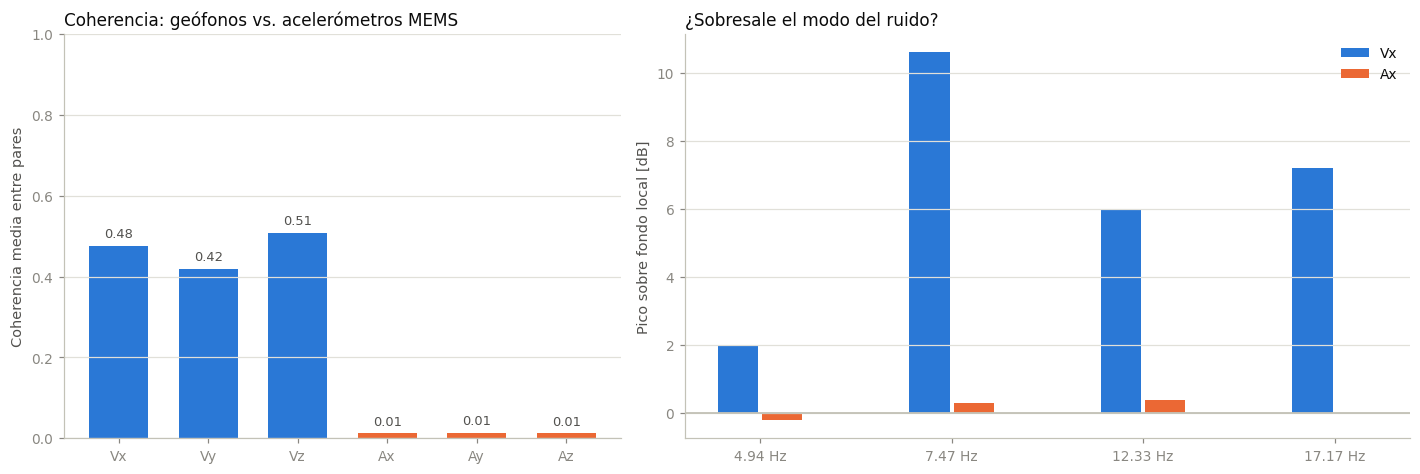

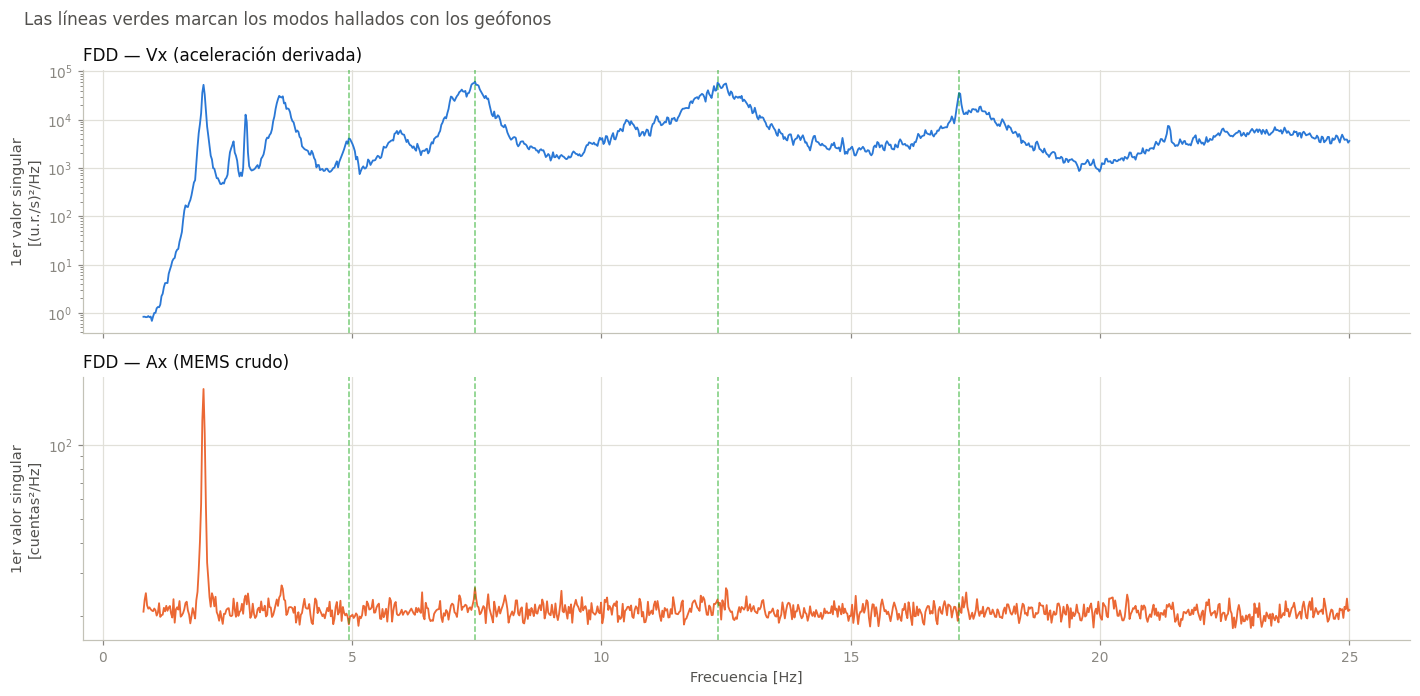

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4),
                         gridspec_kw={"width_ratios": [1, 1.3]})

# --- coherencia por canal ---
cols_bar = [CAT[0] if c[0] == "V" else CAT[1] for c in calidad.index]
axes[0].bar(calidad.index, calidad["Coherencia media"], color=cols_bar, width=0.66)
axes[0].set_ylabel("Coherencia media entre pares")
axes[0].set_ylim(0, 1)
axes[0].set_title("Coherencia: geófonos vs. acelerómetros MEMS", loc="left")
axes[0].grid(axis="x", visible=False)
for i, v in enumerate(calidad["Coherencia media"]):
    axes[0].text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=8.5, color=INK2)

# --- SNR en las frecuencias modales ---
w, xs = 0.2, np.arange(len(F_MODOS))
for k, ch in enumerate([CHANNEL_GEO, "Ax"]):
    vals = [calidad.loc[ch, f"SNR {f:.2f} Hz [dB]"] for f in F_MODOS]
    axes[1].bar(xs + (k - 0.5) * w * 1.15, vals, width=w * 1.05,
                color=CAT[k], label=ch)
axes[1].axhline(0, color="#c3c2b7", linewidth=1.2)
axes[1].set_xticks(xs, [f"{f:.2f} Hz" for f in F_MODOS])
axes[1].set_ylabel("Pico sobre fondo local [dB]")
axes[1].set_title("¿Sobresale el modo del ruido?", loc="left")
axes[1].legend()
axes[1].grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

# --- espectros superpuestos: velocidad y aceleración, escalas propias ---
fig, axes = plt.subplots(2, 1, figsize=(13, 6.4), sharex=True)
for ax, ch, u in [(axes[0], CHANNEL_GEO, UNIDAD_PSD), (axes[1], "Ax", "cuentas²/Hz")]:
    Xc, fsc = CACHE[ch]
    fq, s_, _, _ = fdd(Xc, fsc)
    ax.semilogy(fq, s_[:, 0], color=CAT[0] if ch[0] == "V" else CAT[1], linewidth=1.2)
    for fm in F_MODOS:
        ax.axvline(fm, color=STATUS["modo estructural"], linewidth=1, linestyle="--", alpha=0.55)
    ax.set_ylabel(f"1er valor singular\n[{u}]")
    ax.set_title(f"FDD — {ch}" + (f" ({MAGNITUD} derivada)" if ch[0] == "V" else " (MEMS crudo)"), loc="left")
axes[1].set_xlabel("Frecuencia [Hz]")
fig.suptitle("Las líneas verdes marcan los modos hallados con los geófonos",
             x=0.02, ha="left", fontsize=11, color=INK2)
plt.tight_layout()
plt.show()

### Densidad espectral por sensor — `Ax` y `Ay`

Las 10 curvas de cada canal MEMS, en su propia escala. Las líneas verdes marcan las cuatro frecuencias modales obtenidas con los geófonos.

Lo que se ve: espectros planos, las 10 curvas superpuestas en el mismo nivel de ruido, sin resonancias en las líneas verdes. El único rasgo es el pico de maquinaria de ~2 Hz. Compáralo con la PSD de los geófonos del paso 4, donde cada sensor tiene su propio nivel y las resonancias se ven a simple vista.

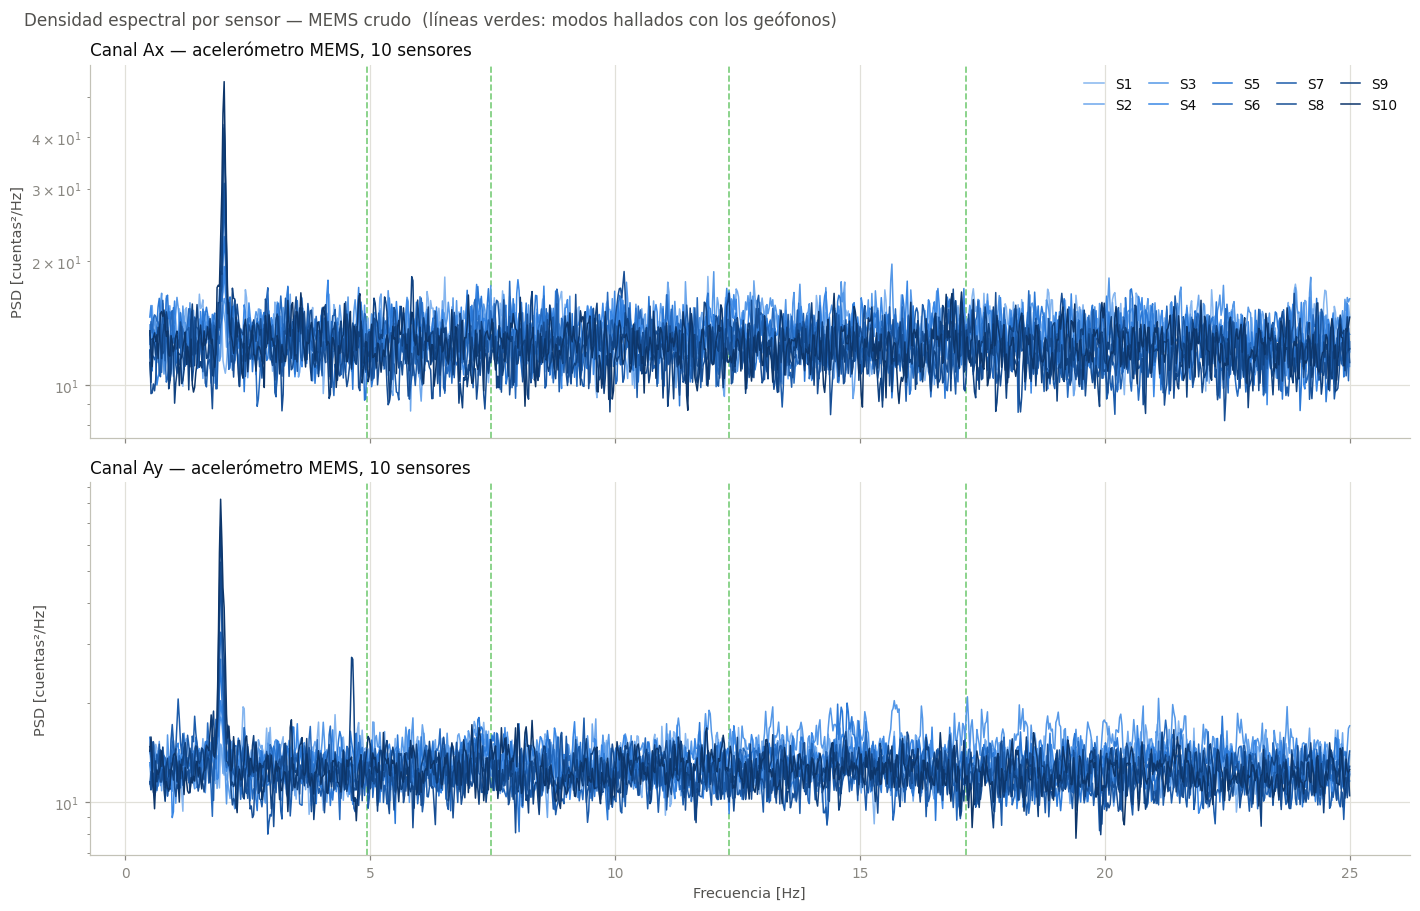

Canal    PSD mediana   dispersión entre sensores


Ax              12.7                     1.13x


Ay              12.7                     1.22x

Una dispersión cercana a 1x significa que los 10 sensores comparten el mismo
nivel: es el piso de ruido del equipo, no una respuesta estructural.


In [18]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8.4), sharex=True)

for ax, ch in zip(axes, ["Ax", "Ay"]):
    Xc, fsc = CACHE[ch]
    for k in range(Xc.shape[1]):
        fw, Pw = welch(Xc[:, k], fs=fsc, nperseg=NPERSEG)
        m = (fw >= 0.5) & (fw <= FMAX)
        ax.semilogy(fw[m], Pw[m], color=SEQ10[k], linewidth=1.0, label=f"S{k+1}")
    for fm in F_MODOS:
        ax.axvline(fm, color=STATUS["modo estructural"], linewidth=1.1,
                   linestyle="--", alpha=0.55, zorder=1)
    ax.set_ylabel(f"PSD [cuentas²/Hz]")
    ax.set_title(f"Canal {ch} — acelerómetro MEMS, 10 sensores", loc="left")

axes[0].legend(ncol=5, loc="upper right", columnspacing=1.2, handlelength=1.4)
axes[1].set_xlabel("Frecuencia [Hz]")
fig.suptitle("Densidad espectral por sensor — MEMS crudo  "
             "(líneas verdes: modos hallados con los geófonos)",
             x=0.02, ha="left", fontsize=11, color=INK2)
plt.tight_layout()
plt.show()

# --- nivel de ruido y dispersión entre sensores en la banda modal ---
print(f"{'Canal':<6}{'PSD mediana':>14}{'dispersión entre sensores':>28}")
for ch in ["Ax", "Ay"]:
    Xc, fsc = CACHE[ch]
    niveles = []
    for k in range(Xc.shape[1]):
        fw, Pw = welch(Xc[:, k], fs=fsc, nperseg=NPERSEG)
        b = (fw >= 4) & (fw <= 20)
        niveles.append(np.median(Pw[b]))
    niveles = np.array(niveles)
    print(f"{ch:<6}{np.median(niveles):>14.1f}"
          f"{niveles.max()/niveles.min():>25.2f}x")
print("\nUna dispersión cercana a 1x significa que los 10 sensores comparten el mismo")
print("nivel: es el piso de ruido del equipo, no una respuesta estructural.")

In [19]:
# --- identificación modal directa sobre Ax, Ay, Az ---
acc = pd.concat([identificar(c) for c in ["Ax", "Ay", "Az"]], ignore_index=True)

print("Picos detectados en los canales de aceleración:")
display(acc.sort_values(["Canal", "f [Hz]"]).set_index(["Canal", "f [Hz]"]))

est_acc = acc[acc["clase"] == "modo estructural"]
print(f"\nCandidatos a modo estructural en Ax/Ay/Az: {len(est_acc)}")
for f_ in F_MODOS:
    hit = acc[(acc["f [Hz]"] - f_).abs() < 0.15]
    print(f"   modo {f_:6.3f} Hz  ->  "
          + ("detectado en " + ", ".join(hit["Canal"]) if len(hit) else "NO detectado"))

Picos detectados en los canales de aceleración:


,,prom [dB],sv1/sv2,ζ [%],nodos,clase
Canal,f [Hz],,,,,
aX (MEMS),2.023,9.6,9.0,2.38,0,modo estructural
aY (MEMS),1.951,11.5,12.4,2.47,0,modo estructural



Candidatos a modo estructural en Ax/Ay/Az: 2
   modo  4.937 Hz  ->  NO detectado
   modo  7.466 Hz  ->  NO detectado
   modo 12.330 Hz  ->  NO detectado
   modo 17.171 Hz  ->  NO detectado


### Veredicto

**Los acelerómetros de este registro no permiten identificar los modos.**

- Coherencia media entre pares ≈ **0.01** en `Ax`, `Ay` y `Az`, frente a 0.4–0.5 en
  los geófonos. Con coherencia 0.01 cada acelerómetro está midiendo su propio
  ruido electrónico, no una respuesta estructural común.
- La relación pico/fondo en las cuatro frecuencias modales es de **≈ 0 dB**: los
  modos sencillamente no sobresalen del ruido. En `Vx` sobresalen entre 4 y 9 dB.
- El único pico que aparece en aceleración (~2.0 Hz en `Ax` y `Ay`) es el tono de
  maquinaria del paso 7, el único con energía suficiente para superar el ruido.
  `Az` no detecta nada.

**Por qué.** La desviación típica de los canales de aceleración es de 40–86 cuentas
sobre un fondo de escala de ±2 g en 24 bits: la señal ocupa del orden de 10⁻⁵ del
rango. A eso se suma la física: para un movimiento armónico, `a = 2πf·v`, así que a
frecuencias bajas la aceleración asociada a la vibración ambiental es diminuta. Un
geófono, que mide velocidad con una bobina móvil, es órdenes de magnitud más
sensible en esta banda. Los MEMS de este equipo están pensados para sismos o
voladuras, no para vibración ambiental de amplitud micrométrica.

Esto **no es un fallo del método**: el mismo pipeline, sobre los mismos 10 sensores
y la misma ventana temporal, extrae los modos de los canales de velocidad.

## Paso 11 — Aceleración derivada del geófono

Si lo que hace falta es trabajar en aceleración, la vía correcta con estos datos no
es el MEMS sino **derivar la señal del geófono**: `a(t) = dv/dt`, que conserva la
relación señal/ruido del geófono.

Un detalle que conviene tener claro: derivar multiplica el espectro por `(2πf)²`,
un **escalar real en cada frecuencia**. Al multiplicar toda la matriz G(f) por un
escalar, la SVD devuelve exactamente los mismos vectores singulares. Es decir,
**las frecuencias y las formas modales son idénticas a las obtenidas con
velocidad** — lo que cambia es la unidad y el peso relativo de las zonas del
espectro (la derivada realza las altas frecuencias).

La celda siguiente lo verifica con el MAC entre ambos juegos de formas.

=== Identificación sobre aceleración derivada de Vx ===


,f [Hz],prom [dB],sv1/sv2,ζ [%],nodos,clase
0,2.023000,20.600000,5654.300000,2.380000,0,armónico/fuente
1,2.625000,7.300000,220.200000,3.210000,0,armónico/fuente
2,2.866000,11.600000,818.100000,1.260000,0,armónico/fuente
3,3.540000,16.200000,341.700000,4.420000,0,armónico/fuente
4,4.937000,6.900000,10.900000,2.930000,0,modo estructural
5,5.973000,5.100000,24.000000,3.830000,1,modo estructural
6,7.466000,18.600000,163.600000,2.420000,1,modo estructural
7,12.330000,16.100000,108.000000,1.760000,1,modo estructural
8,17.171000,12.900000,64.900000,0.350000,2,modo estructural


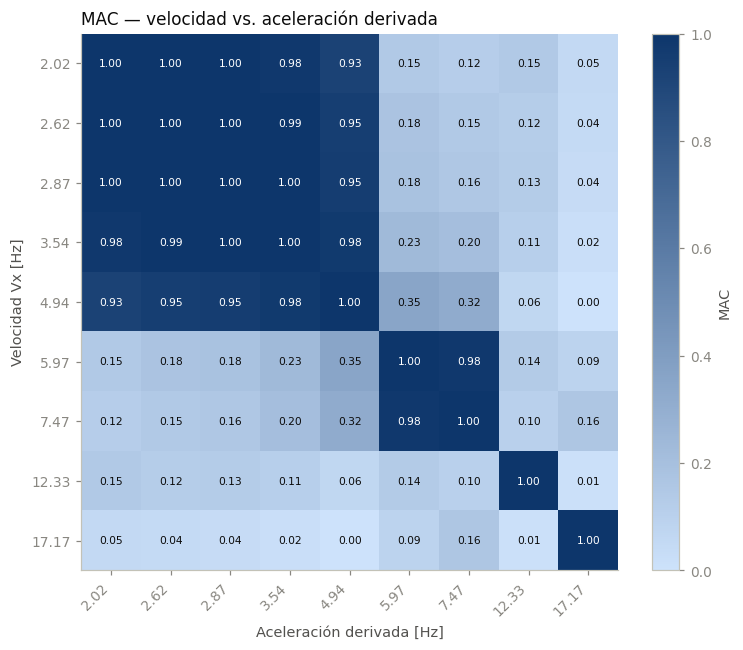

MAC en la diagonal: mín = 1.000, medio = 1.000
Las formas modales coinciden: derivar no cambia la identificación.


In [20]:
# --- aceleración derivada de los geófonos ---
Xv, fsv, _ = load_channel_matrix(files, CHANNEL_GEO, dominio="velocidad")  # geófono sin derivar
Xa = np.gradient(Xv, 1 / fsv, axis=0)               # d/dt: velocidad -> aceleración

fq_a, sv_a, U_a, _ = fdd(Xa, fsv)
db_a = 10 * np.log10(sv_a[:, 0])
pk_a, pr_a = find_peaks(db_a, prominence=5,
                        distance=max(1, int(0.10 / (fq_a[1] - fq_a[0]))))

reg_a = []
for k, i in enumerate(pk_a):
    phi = mode_shape(U_a, i)
    ratio = sv_a[i, 0] / sv_a[i, 1]
    z = half_power_damping(fq_a, db_a, i)
    ns = n_sign_changes(phi)
    reg_a.append({"i": i, "f [Hz]": round(float(fq_a[i]), 3),
                  "prom [dB]": round(float(pr_a["prominences"][k]), 1),
                  "sv1/sv2": round(float(ratio), 1), "ζ [%]": round(float(z), 2),
                  "nodos": ns, "clase": classify(ratio, z, ns)})
peaks_a = pd.DataFrame(reg_a)

print(f"=== Identificación sobre aceleración derivada de {CHANNEL_GEO} ===")
display(peaks_a.drop(columns="i").style.apply(
    lambda c: [f"color: {STATUS.get(v, INK)}; font-weight: 600" for v in c]
    if c.name == "clase" else ["" for _ in c], axis=0))

# --- MAC entre formas de velocidad y de aceleración derivada ---
# `peaks`/`U` vienen del canal CHANNEL; si CHANNEL no es el geófono de referencia,
# se recalcula sobre CHANNEL_GEO para que la comparación sea del mismo eje.
if CHANNEL == CHANNEL_GEO:
    U_ref, peaks_ref = U, peaks
else:
    _fq, _sv, U_ref, _ = fdd(Xv, fsv)
    _db = 10 * np.log10(_sv[:, 0])
    _pk, _pr = find_peaks(_db, prominence=5,
                          distance=max(1, int(0.10 / (_fq[1] - _fq[0]))))
    peaks_ref = pd.DataFrame([{"i": i, "f [Hz]": round(float(_fq[i]), 3)} for i in _pk])

Pv = np.array([mode_shape(U_ref, int(r["i"])) for _, r in peaks_ref.iterrows()])
Pa = np.array([mode_shape(U_a, int(r["i"])) for _, r in peaks_a.iterrows()])
num = np.abs(Pv.conj() @ Pa.T) ** 2
Mva = num / np.outer(np.real(np.sum(np.abs(Pv) ** 2, 1)),
                     np.real(np.sum(np.abs(Pa) ** 2, 1)))

fig, ax = plt.subplots(figsize=(7.2, 6))
im = ax.imshow(Mva, cmap=CMAP_SEQ, vmin=0, vmax=1)
ax.set_xticks(range(len(peaks_a)), [f"{v:.2f}" for v in peaks_a["f [Hz]"]],
              rotation=45, ha="right")
ax.set_yticks(range(len(peaks_ref)), [f"{v:.2f}" for v in peaks_ref["f [Hz]"]])
ax.set_xlabel("Aceleración derivada [Hz]")
ax.set_ylabel(f"Velocidad {CHANNEL_GEO} [Hz]")
ax.set_title("MAC — velocidad vs. aceleración derivada", loc="left")
ax.grid(visible=False)
for i in range(Mva.shape[0]):
    for j in range(Mva.shape[1]):
        ax.text(j, i, f"{Mva[i,j]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if Mva[i, j] > 0.55 else INK)
plt.colorbar(im, ax=ax, fraction=0.046, label="MAC")
plt.tight_layout()
plt.show()

k = min(Mva.shape)
if k:
    diag = np.diag(Mva[:k, :k])
    print(f"MAC en la diagonal: mín = {diag.min():.3f}, medio = {diag.mean():.3f}")
    print("Las formas modales coinciden: derivar no cambia la identificación."
          if diag.min() > 0.99 else "Revisar: las formas no coinciden exactamente.")
else:
    print("Sin picos que comparar.")

RMS de aceleración derivada por sensor [unidades relativas/s]
(proporcional a la aceleración; sin calibrar en m/s², ver nota del paso 1)
   S1       1972.4
   S2        644.5
   S3       1114.4
   S4       1862.2
   S5        832.7
   S6        441.3
   S7        657.8
   S8        412.0
   S9        482.6
   S10       594.2


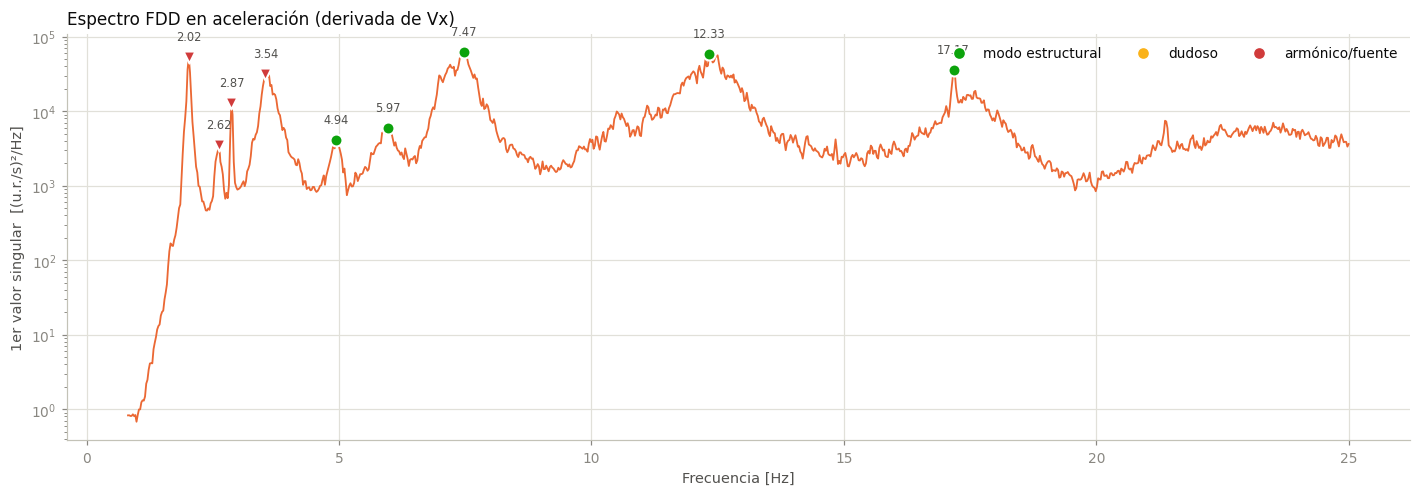

In [21]:
# --- amplitud modal en unidades de aceleración ---
modos_acc = peaks_a[peaks_a["clase"] == "modo estructural"].copy()
rms_acc = [float(np.sqrt(np.mean(Xa[:, k] ** 2))) for k in range(Xa.shape[1])]

print("RMS de aceleración derivada por sensor [unidades relativas/s]")
print("(proporcional a la aceleración; sin calibrar en m/s², ver nota del paso 1)")
for k, v in enumerate(rms_acc, 1):
    print(f"   S{k:<2}  {v:10.1f}")

fig, ax = plt.subplots(figsize=(13, 4.6))
ax.semilogy(fq_a, sv_a[:, 0], color=CAT[1], linewidth=1.2, zorder=2)
for _, r in peaks_a.iterrows():
    ax.scatter(r["f [Hz]"], sv_a[int(r["i"]), 0], s=62,
               marker="o" if r["clase"] == "modo estructural" else "v",
               color=STATUS[r["clase"]], edgecolor="white", linewidth=1.4, zorder=3)
    ax.annotate(f"{r['f [Hz]']:.2f}", (r["f [Hz]"], sv_a[int(r["i"]), 0]),
                textcoords="offset points", xytext=(0, 11), ha="center",
                fontsize=7.5, color=INK2)
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel("1er valor singular  [(u.r./s)²/Hz]")   # aceleración
ax.set_title(f"Espectro FDD en aceleración (derivada de {CHANNEL_GEO})", loc="left")
handles = [plt.Line2D([], [], marker="o", linestyle="", markersize=8,
                      markerfacecolor=v, markeredgecolor="white", label=k)
           for k, v in STATUS.items()]
ax.legend(handles=handles, ncol=3, loc="upper right")
plt.tight_layout()
plt.show()

## Paso 12 — Exportación (opcional)

Convierte los `.bin` a `.mat` / `.csv` / `.pkl` / `.npz`.

> Con 710 227 muestras × 6 canales cada CSV pesa ~250 MB. Está **desactivado por
> defecto**; pon `RUN_EXPORT = True` para ejecutarlo.

In [22]:
RUN_EXPORT = False
FORMATOS = ["mat", "npz"]          # añade "csv" / "pkl" si los necesitas

if RUN_EXPORT:
    os.makedirs(POST_DIR, exist_ok=True)
    for fn in files:
        path = os.path.join(DATA_DIR, fn)
        d, fs_e, _ = load_file(path)
        hdr = read_header(path)
        stem = os.path.splitext(fn)[0]
        if "mat" in FORMATOS:
            savemat(os.path.join(POST_DIR, stem + ".mat"),
                    {"data": d.values, "columns": d.columns.tolist(),
                     "fs": fs_e, "header": hdr})
        if "npz" in FORMATOS:
            np.savez_compressed(os.path.join(POST_DIR, stem + ".npz"),
                                data=d.values, fs=fs_e, columns=d.columns.tolist())
        if "csv" in FORMATOS:
            d.to_csv(os.path.join(POST_DIR, stem + ".csv"), index=False)
        if "pkl" in FORMATOS:
            d.to_pickle(os.path.join(POST_DIR, stem + ".pkl"))
        print("  exportado:", stem)
    print("Listo ->", POST_DIR)
else:
    print("Exportación desactivada (RUN_EXPORT = False).")

Exportación desactivada (RUN_EXPORT = False).
